In [1]:
# loading modules
using PyPlot, Printf, LinearAlgebra, FFTW, FileIO, JLD2

using CUDA

using Setfield

# include("../../LinStab/mjcl_stab.jl")
# using .LinStab

using FourierFlows: CPU, TwoDGrid, plan_flows_rfft

using GeophysicalFlows

using Glob

using Statistics

using Parameters

using StaticArrays, KernelAbstractions

run_file_dir = "/scratch/cimes/ml1994/QG/julia/QG_topo/"
include(run_file_dir * "mjcl_gfjl_fcns.jl")


calc_Ld_modes (generic function with 1 method)

# Defining model parameters

In [2]:

dev = GeophysicalFlows.CPU()

Ny = Nx = n = 1024                # 2D resolution = n²


###################################################################################
## Geometry and background fields
###################################################################################

Nz = nlayers = 2                 # number of layers
f0 = f₀= 8.3e-5            # Coriolis param [s^-1]
g = 9.81                    # gravity
H = [2000., 2000.]     # the rest depths of each layer;

Us = [0.01, 0.017634058790440166, 0.024]
rhos = 1025.75 - 0.5775

kt = 0.

rho0 = 1025.        # Boussinesq reference density

# always zero for now, model can't even take this in as a parameter...
V = zeros(nlayers)


# running model

rho = ρ = [0., 1025.75]
rho[1] = ρ[1] = rhos[1]

strat_str = "uni_strat"
shear_str = "uni_shear"

# change U here
U = [0.,0.]
U[1] = Us[1]

gprime = (g/rho0)*(ρ[2] - ρ[1])

Ld = sqrt(gprime * sum(H)) / 2 / f0

L = Lx = Ly = 25*2*pi*Ld   # domain size [m]

###################################################################################
## Planetary PV gradient
###################################################################################
betas = βs = collect(range(-1.5,1.5,13)) * (U[1]/2) * Ld^-2
β = 0. # 1e-11              # the y-gradient of planetary PV; beta = β = 0. * (U[1]/2) * Ld^-2

###################################################################################
## Topography
###################################################################################

# set topography w/ current options:
topo_type = "y_slope"

# Defining a bulk slope parameter...should probably change this!

# setting slope(s)
S32 = f0 * U[1] / gprime

dyetab_over_S32 = collect(range(-1.5,1.5,13))
h0s = dyetab_over_S32 .* S32
# h0s = h0s[7:end]

# tuple of (bottom slope, h_rms)
h0 = (h0s[1], 0.)    #

# central wavenumber for rough topo
kt = 0.

# defining GFJL topo params
interim_params = mod_params(topo_type=topo_type, h0=h0, kt=kt)

topographic_pv_gradient, eta = define_topo(interim_params)

###################################################################################
# Dissipation
###################################################################################

# biharmonic viscosity
nν = 4
νstar = 0. # 10^-13
ν = νstar * ((U[1]-U[end])/2) * (Lx/2/pi)^7

dyn_nu = false

# Linear bottom drag
μstars = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
mus = @. μstars * ((U[1]-U[end]) / 2) / Ld

# Quadratic bottom drag
κstars = [0.]
kappas = [0.] # @. κstars / Ld

###################################################################################
## Time stepping and sample rate
###################################################################################

if ν==0.
    stepper = "FilteredETDRK4"
    # af = 0.
    # global filt_order=4
    # global innerK = 2/3
else
    stepper = "ETDRK4"
    # af = 1/3
    # global filt_order=4
    # innerK = 2/3
end

# should I set dt via CFL condition instead?
dt = 600.

###################################################################################
## Details of saving data
###################################################################################
global diags = diag_bools(two_layer_kspace_modal_nrg_budget_bool=true);

# where to save model output; frequency of output
data_dir = "/scratch/cimes/ml1994/QG/julia/data/sloping_LD_two_layer_data/"

f_s = 5. * (Ld / ((U[1]-U[end])/2)) #  N eddy turnover periods

# sampling period in time steps (set above)
nsubs = round(Int64, f_s/dt)

###################################################################################
## Model run parameters
###################################################################################

# steady-state  parameters
ss_yr_max = ceil(100 * (Ld / ((U[1]-U[end])/2)) / 3600 / 24 / 365.25)  # number of eddy periods converted to years for model run
yr_increment = 1.0 # how often to write to a save file

restart_bool = false

pre_buoy_restart_file = true
data_dir_pre_buoy = "/scratch/cimes/ml1994/QG/julia/data/two_layer_drag_study/"

###################################################################################
## Define params struct
###################################################################################
global model_params = mod_params(
data_dir = data_dir,
Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
H = H,
rho0 = rho0, rho = rho, strat_str = strat_str,
shear_str = shear_str, U = U,
μ = mus[1], κ = kappas[1], nν = nν, ν = ν, dyn_nu = dyn_nu,
eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
β = β,
dt = dt,
stepper = stepper,
dev = dev,
restart_bool = restart_bool,
pre_buoy_restart_file = pre_buoy_restart_file,
data_dir_pre_buoy = data_dir_pre_buoy,
ss_yr_max = ss_yr_max,
yr_increment = yr_increment,
nsubs = nsubs)

###################################################################################
## Initialize model
###################################################################################

prob, prob_filt = initialize_model(model_params);

# prob = set_initial_conditions(prob, prob_filt, model_params)

sol, clock, params, vars, grid = prob.sol, prob.clock, prob.params, prob.vars, prob.grid;




In [3]:
dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE);


In [4]:
function redef_mu_kappa(model_params, mu, kappa)
    @unpack_mod_params model_params

    mp_out = mod_params(
    data_dir = data_dir,
    Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
    H = H,
    rho0 = rho0, rho = rho, strat_str = strat_str,
    shear_str = shear_str, U = U,
    μ = mu , κ = kappa , nν = nν, ν = ν, dyn_nu=dyn_nu,
    eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
    β = β,
    dt = dt,
    stepper = stepper,
    dev = dev,
    restart_bool = restart_bool,
    ss_yr_max = ss_yr_max,
    yr_increment = yr_increment,
    nsubs = nsubs);

    return mp_out
end

redef_mu_kappa (generic function with 1 method)

In [5]:
using PlotUtils

cm = cgrad(:coolwarm);
clrs = [cm[i] for i in range(0,1,100)]

hc_range = collect(range(h0s[1],h0s[end],100))

function h_color(h_in,hc_range,colors)
    c_ind = argmin(abs.(h_in .- (hc_range)))

    color_out = [red(clrs[c_ind]),green(clrs[c_ind]),blue(clrs[c_ind])]

    if h_in==0
        color_out = [0.,0.,0.]
    end
    return color_out
end

####################################################################
## 
####################################################################

function plot_info_box(ax, var, x, y, plus_mode, fsize)
    textstr = var * "\n" * L"+ \rightarrow" * plus_mode

    # these are matplotlib.patch.Patch properties
    props = Dict("boxstyle"=>"round", "facecolor"=>"wheat", "alpha"=>0.5)
    
    # place a text box in upper left in axes coords
    ax.text(x, y, textstr, transform=ax.transAxes, fontsize=fsize,
            ha="left", va="top", bbox=props)

    return nothing
end


####################################################################
## 
####################################################################


# tab20_range = collect(range(0,1,20))

function tab20_color(c_ind)

    cm2 = cgrad(:tab20);
    clrs2 = [cm2[i] for i in range(0,1,20)]

    color_out = [red(clrs2[c_ind]),green(clrs2[c_ind]),blue(clrs2[c_ind])]

    return color_out
end



tab20_color (generic function with 1 method)

# Checking which files we have

In [46]:
# global model_params = redef_mu_kappa_topoPV_h0(model_params, mus[1], kappas[1], (0., 0.), (h0s[1], 0.))
# global topo_PV, eta = define_topo(model_params)
# model_params = redef_mu_kappa_topoPV_h0(model_params, mus[1], kappas[1], topo_PV, (h0s[1], 0.))

# file1 = jld_name(model_params,1)
# files = glob(file1[2:findfirst("yr",file1)[2]]*"*", data_dir)

kappas = @. κstars / Ld
mus = @. μstars * ((U[1]-U[end]) / 2) / Ld


for i in range(1,length(h0s))
    global h0 = (h0s[i], 0.)
    for j in range(1, length(kappas))
        kappa_loc = kappas[j]
        for k in range(1, length(mus))
            mu_loc = mus[k]

            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
            global topo_PV, eta = define_topo(model_params)
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

            file1 = jld_name(model_params,1)
            files = glob(file1[2:findfirst("yr",file1)[2]]*"*", data_dir)
            
            N_files = round(Int, (length(files)))

            yr_output = zeros(N_files)
            for (i, file) in enumerate(files)
                yr_output[i] = parse(Float64,file[findfirst("yr",file)[2]+1:findfirst(".jld",file)[1]-1])
            end
            
            yr_output = sort(yr_output)

            kap_str = @sprintf "%.3E" kappa_loc
            mu_str = @sprintf "%.3E" mu_loc
            h_str = "_" * topo_type * "_h0_" * (@sprintf "%.3E" h0[1])

            if isempty(yr_output)
                println(kap_str * mu_str * h_str * ": " * string(0.0))
            else
                println(kap_str * mu_str * h_str * ":  " * string(yr_output[end]))
            end
        end
    end
end





0.000E+004.413E-08_y_slope_h0_-2.253E-04:  62.95
0.000E+008.826E-08_y_slope_h0_-2.253E-04:  62.95
0.000E+001.765E-07_y_slope_h0_-2.253E-04:  62.95
0.000E+003.530E-07_y_slope_h0_-2.253E-04:  62.95
0.000E+007.061E-07_y_slope_h0_-2.253E-04:  62.95
0.000E+004.413E-08_y_slope_h0_-1.877E-04:  62.95
0.000E+008.826E-08_y_slope_h0_-1.877E-04:  62.95
0.000E+001.765E-07_y_slope_h0_-1.877E-04:  62.95
0.000E+003.530E-07_y_slope_h0_-1.877E-04:  62.95
0.000E+007.061E-07_y_slope_h0_-1.877E-04:  62.95
0.000E+004.413E-08_y_slope_h0_-1.502E-04:  62.95
0.000E+008.826E-08_y_slope_h0_-1.502E-04:  62.95
0.000E+001.765E-07_y_slope_h0_-1.502E-04:  62.95
0.000E+003.530E-07_y_slope_h0_-1.502E-04:  62.95
0.000E+007.061E-07_y_slope_h0_-1.502E-04:  62.95
0.000E+004.413E-08_y_slope_h0_-1.126E-04:  54.75
0.000E+008.826E-08_y_slope_h0_-1.126E-04:  62.95
0.000E+001.765E-07_y_slope_h0_-1.126E-04:  62.95
0.000E+003.530E-07_y_slope_h0_-1.126E-04:  62.95
0.000E+007.061E-07_y_slope_h0_-1.126E-04:  62.95
0.000E+004.413E-08_y

In [41]:

betas[1]

-9.348034737941376e-12

# Loading diagnostics for a given combination of drag and slope


In [22]:

i=7
j=1
k=1


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]
beta = betas[11]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)


global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name(model_params,62.95))

    

# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_0.000E+00_beta3.116E-12_uni_shear_uni_strat_mu8.826E-08_kappa0.000E+00_nu0.000E+00_res1024_yr57.7.jld


# betas that don't equilibrate:
# kappa*=4.0 : beta10+; beta11+ are decreasing, i.e., there is no instability???
# kappa*=2.0 : beta12+ (11 has growth, but averaged energy budget still closes)
# kappa*=1.0 : beta13
# kappa*=0.5 : okay
# kappa*=0.25 : definitely 10 good; maybe 11? secular growth but low residuals
# kappa*=0.125 : beta11+


Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.0289308, "t"=>[1.70411e9, 1.70…

In [218]:
a["jld_data"]

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr54.05.jld

# jld_name(model_params,54.05)



Dict{String, Any} with 9 entries:
  "ph_slices"                         => 0.0289308
  "t"                                 => [1.70411e9, 1.70411e9, 1.70417e9, 1.70…
  "two_layer_xspace_modal_nrg_budget" => [2.71606e-5; 7.88858e-6; … ; 1.28303e-…
  "psi_yrs_end"                       => [-171.017 -146.641 … -228.211 -198.516…
  "two_layer_xspace_nrgs_ot"          => [5.56941e-5 5.56993e-5 … 0.0 0.0; 6.60…
  "two_layer_vBT_scale"               => 0.00736523
  "two_layer_kspace_modal_nrg_budget" => [0.0 0.0 … 0.0 -2.84408e-36; 0.179331 …
  "ph_iso"                            => 0.0313737
  "two_layer_modal_length_scales"     => [2.47179e-5; 2.73813e-5;;]

-0.0032955018825786067


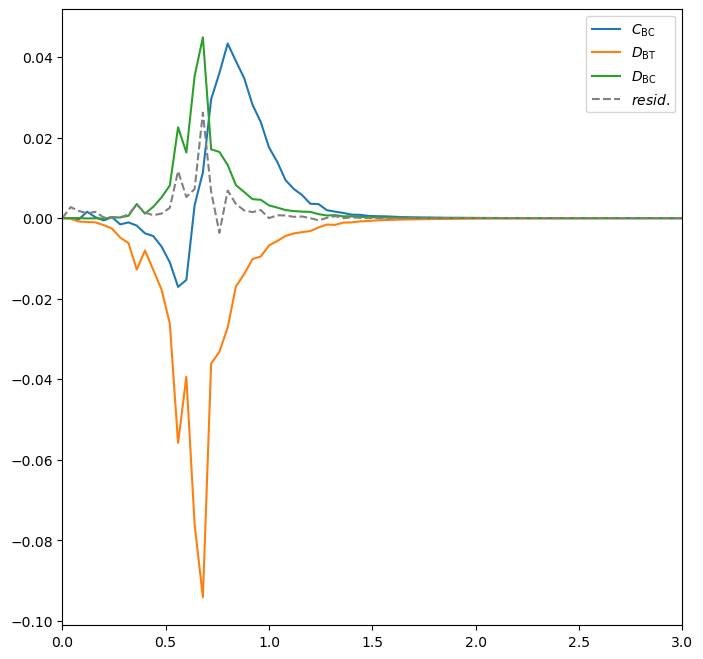

PyObject <matplotlib.legend.Legend object at 0x149d5790c220>

In [219]:
fig,ax = plt.subplots(1,1, figsize=(8,8))

norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
ax.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}")
ax.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* norm, label=L"D_\mathrm{BT}")
ax.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")


# ax.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7])

ax.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm, color="gray", linestyle="--", label=L"resid.")

# ax.plot(grid.kr*Ld, sum(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7:13], dims=2) .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4], "k--")

println(sum(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7]))

ax.set_xlim(0., 3.)
ax.legend()

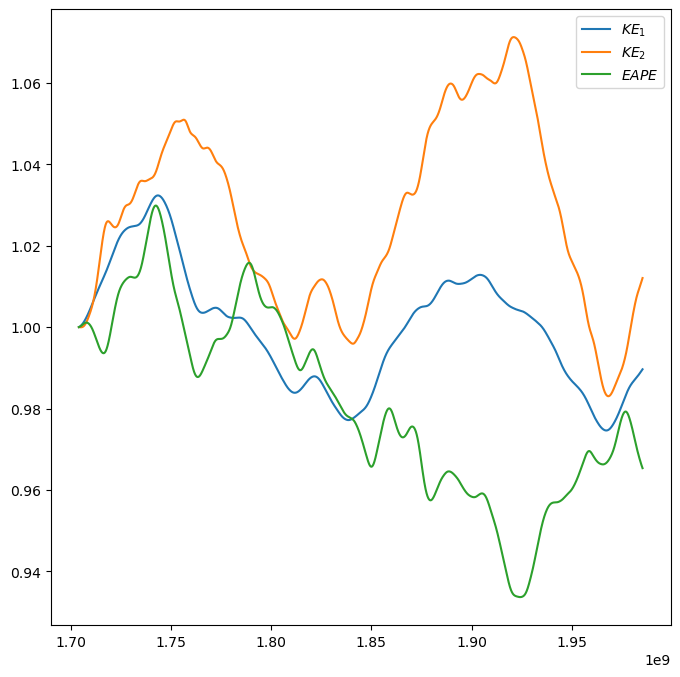

PyObject <matplotlib.legend.Legend object at 0x149d571c8a30>

In [216]:
fig,ax = plt.subplots(1,1, figsize=(8,8))

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1], label=L"KE_{1}")

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][2,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][2,1], label=L"KE_{2}")

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][3,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][3,1], label=L"EAPE")

ax.legend()


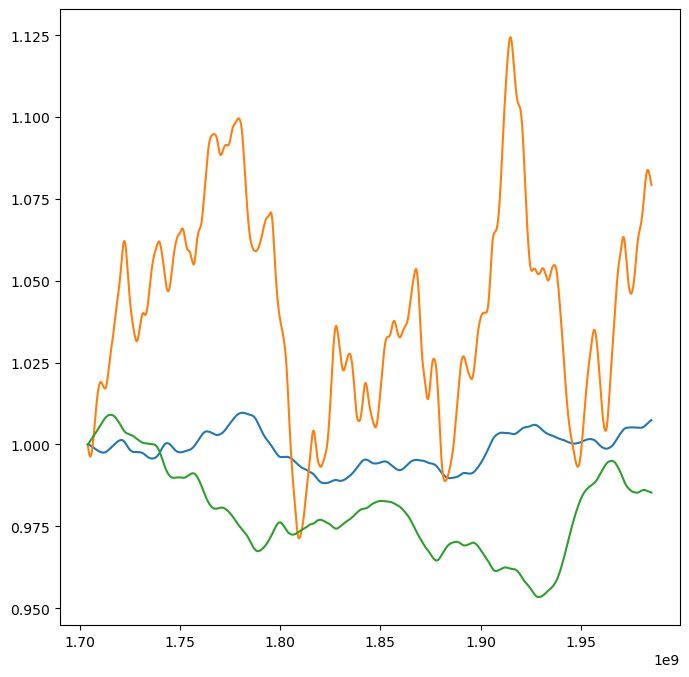

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x152aa81a8640>

In [9]:
fig,ax = plt.subplots(1,1, figsize=(8,8))

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1])

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][2,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][2,1])

ax.plot(a["jld_data"]["t"][2:end], a["jld_data"]["two_layer_xspace_nrgs_ot"][3,1:length(a["jld_data"]["t"][2:end])] ./ a["jld_data"]["two_layer_xspace_nrgs_ot"][3,1])

In [48]:
# (a["jld_data"]["two_layer_vBT_scale"] / (beta))^0.5

(mus./0.01).^-1

6-element Vector{Float64}:
 453200.5784974396
 226600.2892487198
 113300.1446243599
  56650.07231217995
  28325.036156089976
  14162.518078044988

In [24]:
# (1) BTKE_x, (2) BCKE_x, (3) BCEAPE_x, (4) LT_x, (5) TT_x, (6) BC_x, (7) NL_x, (8) DBT_x, (9) DBC_x, (10) resid_x
xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)

EKE1 = mean(a["jld_data"]["two_layer_xspace_nrgs_ot"][1,1:length(a["jld_data"]["t"][2:end])])
EKE2 = mean(a["jld_data"]["two_layer_xspace_nrgs_ot"][2,1:length(a["jld_data"]["t"][2:end])])

println("EKEBC over EKEBT: " * string(xmn[2] / xmn[1]))   #EKEBC over EKEBT

println("CBC/eps psi: " * string(2*xmn[6] / mus[5] / xmn[1]))  # CBC/ eps_psi

println("CBC/DBT: " * string(-xmn[6] / xmn[8]))           # CBC / DBT

println("CBC / (DBT+DBC): " * string(- xmn[6] / (xmn[8] + xmn[9])))

println("DBC_EAPE / CBC: " * string(2 * xmn[9] / xmn[6]))


println("EKE1 / EKE2: " * string(EKE1/EKE2))   #EKEBC over EKEBT

println("LBC / LBT: " * string(a["jld_data"]["two_layer_modal_length_scales"][1] / a["jld_data"]["two_layer_modal_length_scales"][2]))


EKEBC over EKEBT: 1.0213513694634977
CBC/eps psi: 0.1866834447828765
CBC/DBT: 2.614112981547222
CBC / (DBT+DBC): 1.0062164193439946
DBC_EAPE / CBC: -1.2225660984528877
EKE1 / EKE2: 42.58001727648003
LBC / LBT: 0.9965889295288308


In [21]:

i=8
j=1
k=5


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)



r_file_name = jld_name_pre_buoy(model_params, 62.950)

a = load(r_file_name)

psi = ψ = a["jld_data"]["psi_ot"][:,:,:,1];

LoadError: InexactError: Int64(62.95)

In [34]:
using FileIO, JLD2

data_dir_old = "../../data/two_layer_drag_study/";

fn = data_dir_old*"vel_scales.jld"

# jld_data = Dict("vel_scales_kap0p5" => vel_scales_kap0p5,
#     "vel_scales_kap1" => vel_scales_kap1,
#     "vel_scales_kap2" => vel_scales_kap2,
#     "vel_scales_kap4" => vel_scales_kap4)


# jldsave(fn; jld_data)


a = load(fn);

for (k,v) in a["jld_data"]
    @eval $(Symbol(k)) = $(v)
end

############################################################################
# vel scales are twelve
# total BT, U BT, V BT, total BC, U BC, V BC, total L1, U L1, V L1, total L2, U L2, V L2

# first index is h_ind
# vel_scales_kap0p25[:,vs_ind]

vel_scales_kap0p25[:,3]./vel_scales_kap0p25[:,1]

13-element Vector{Float64}:
 0.698788480928602
 0.7023813062947236
 0.7033318082906206
 0.7006564338014822
 0.7071411449101521
 0.7058848646161534
 0.700914717223211
 0.708061450800578
 0.6972327793079263
 0.6925125929723587
 0.6873395624360139
 0.6883156922003283
 0.6574823054363449

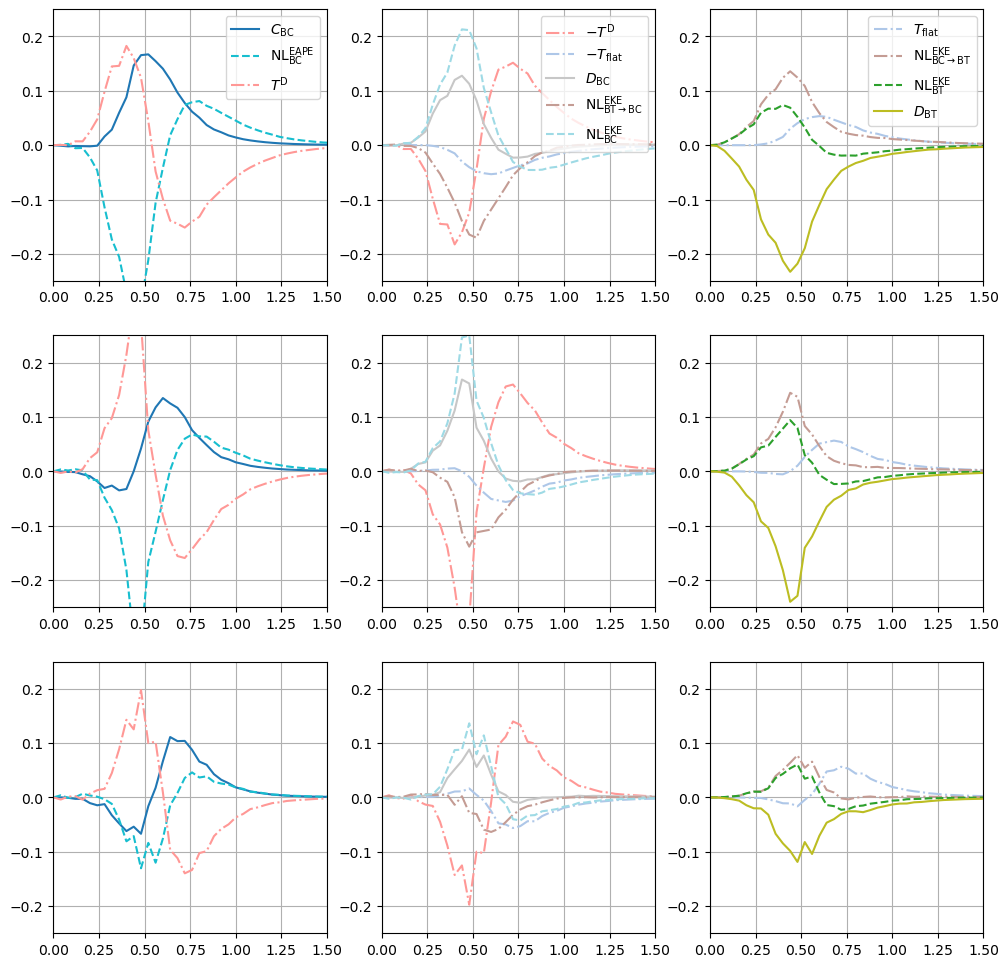

In [8]:
function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

    h0 = (h0s[7], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[k]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name(model_params,62.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
    ##############################################################
    # EAPE budget
    ##############################################################
    # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )

    trans_resid = (-a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )
    
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
    # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    ax1.plot(grid.kr*Ld, trans_resid .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

    # ax1.axvline((0.7 * a["jld_data"]["two_layer_vBT_scale"] / beta)^0.5 / (2 * pi * Ld))
    # ax1.axvline((mu_loc / a["jld_data"]["two_layer_vBT_scale"])^-1 / (2 * pi * Ld))


    # if i==2
    #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
    #     axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

    #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
    #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
    #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    #     axins.plot(grid.kr*Ld, trans_resid .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

    #     axins.set_xlim(0.125, 1.5)
    #     axins.set_ylim(-0.005, 0.005)

    #     axins.set_yticklabels([])
    #     axins.set_xticklabels([])
        
    # end
    
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -trans_resid .* norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(20), linestyle="dashed")    
    
    
    
    
    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* norm , label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    ax1.set_ylim(-0.25, 0.25)
    ax2.set_ylim(-0.25, 0.25)
    ax3.set_ylim(-0.25, 0.25)

    if legend_bool==true
        ax1.legend(loc="upper right")
        ax2.legend(loc="upper right")
        ax3.legend(loc="upper right")
    end

    ax1.grid()
    ax2.grid()
    ax3.grid()

    

end

###################################################################################
###################################################################################

fig,ax = plt.subplots(3,3, figsize=(12,12))

plot_budget(ax[1], ax[4], ax[7], 6, 1, 8, true)

plot_budget(ax[2], ax[5], ax[8], 6, 1, 9, false)

plot_budget(ax[3], ax[6], ax[9], 6, 1, 10, false)


# plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)



In [ ]:
# Late-time snapsots of vorticity
fig, ax = plt.subplots(3,3, figsize=(16,16))

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)



a = load(data_dir*jld_name(model_params,62.95))
ψ = a["jld_data"]["psi_yrs_end"]

grid = prob.grid
        
# assigning basic variables
ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])

ψBCh = deepcopy(vars.uh[:,:,1])
ψBTh = deepcopy(vars.uh[:,:,1])

mul2D!(ψBCh, rfftplan, ψBC)
mul2D!(ψBTh, rfftplan, ψBT)

ζBCh = - grid.Krsq .* ψBCh
ζBTh = - grid.Krsq .* ψBTh

ζBC = deepcopy(vars.u[:,:,1])
ζBT = deepcopy(vars.u[:,:,1])

ldiv2D!(ζBC, rfftplan, ζBCh)
ldiv2D!(ζBT, rfftplan, ζBTh)

betas_zeta = [betas[8], betas[9], betas[10]]
mus_zeta = [mus[2], mus[4], mus[6]]

n=1

for i in range(1,3)
    for j in range(1,3)
        h0 = (0.0, 0.0)
        kappa_loc = kappas[1]
        mu_loc = mus_zeta[j]  
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

        beta = betas_zeta[i]

        global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

        a = load(data_dir*jld_name(model_params,62.95))
        ψ = a["jld_data"]["psi_yrs_end"]
        
        grid = prob.grid
                
        # assigning basic variables
        ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
        ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])
        
        ψBCh = deepcopy(vars.uh[:,:,1])
        ψBTh = deepcopy(vars.uh[:,:,1])
        
        mul2D!(ψBCh, rfftplan, ψBC)
        mul2D!(ψBTh, rfftplan, ψBT)
        
        ζBCh = - grid.Krsq .* ψBCh
        ζBTh = - grid.Krsq .* ψBTh
        
        ζBC = deepcopy(vars.u[:,:,1])
        ζBT = deepcopy(vars.u[:,:,1])
        
        ldiv2D!(ζBC, rfftplan, ζBCh)
        ldiv2D!(ζBT, rfftplan, ζBTh)
    
        
        VBT = deepcopy(vars.u[:,:,1])
        ldiv2D!(VBT, rfftplan, grid.kr .* ψBTh)

        UBT = deepcopy(vars.u[:,:,1])
        ldiv2D!(UBT, rfftplan, - grid.l .* ψBTh)
    
    
        norm = (a["jld_data"]["two_layer_vBT_scale"] / Ld)^-1
        lim = maximum(abs.(ζBT .* norm))/2
        
        ax[n].pcolormesh((ζBT .* norm)', cmap=PyPlot.cm.bwr, vmin=-lim, vmax=lim)

        lim2 = maximum(abs.(VBT))
        
        ax[n].contour((VBT)', vmin=-lim2, vmax=lim2, levels=4, colors="black")

        ax[n].set_xlim(0,512)
        ax[n].set_ylim(0,512)


        n+=1
    end
end


# kappas = @. κstars / Ld
# mus = @. μstars * ((U[1]-U[end]) / 2) / Ld


# for i in range(1,length(h0s))
#     global h0 = (h0s[i], 0.)
#     for j in range(1, length(kappas))
#         kappa_loc = kappas[j]
#         for k in range(1, length(mus))
#             mu_loc = mus[k]

#             global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#             global topo_PV, eta = define_topo(model_params)
#             global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#             file1 = jld_name(model_params,1)
#             files = glob(file1[2:findfirst("yr",file1)[2]]*"*", data_dir)
            
#             N_files = round(Int, (length(files)))

#             yr_output = zeros(N_files)
#             for (i, file) in enumerate(files)
#                 yr_output[i] = parse(Float64,file[findfirst("yr",file)[2]+1:findfirst(".jld",file)[1]-1])
#             end
            
#             yr_output = sort(yr_output)

#             kap_str = @sprintf "%.3E" kappa_loc
#             mu_str = @sprintf "%.3E" mu_loc
#             h_str = "_" * topo_type * "_h0_" * (@sprintf "%.3E" h0[1])

#             if isempty(yr_output)
#                 println(kap_str * mu_str * h_str * ": " * string(0.0))
#             else
#                 println(kap_str * mu_str * h_str * ":  " * string(yr_output[end]))
#             end
#         end
#     end
# end




# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid




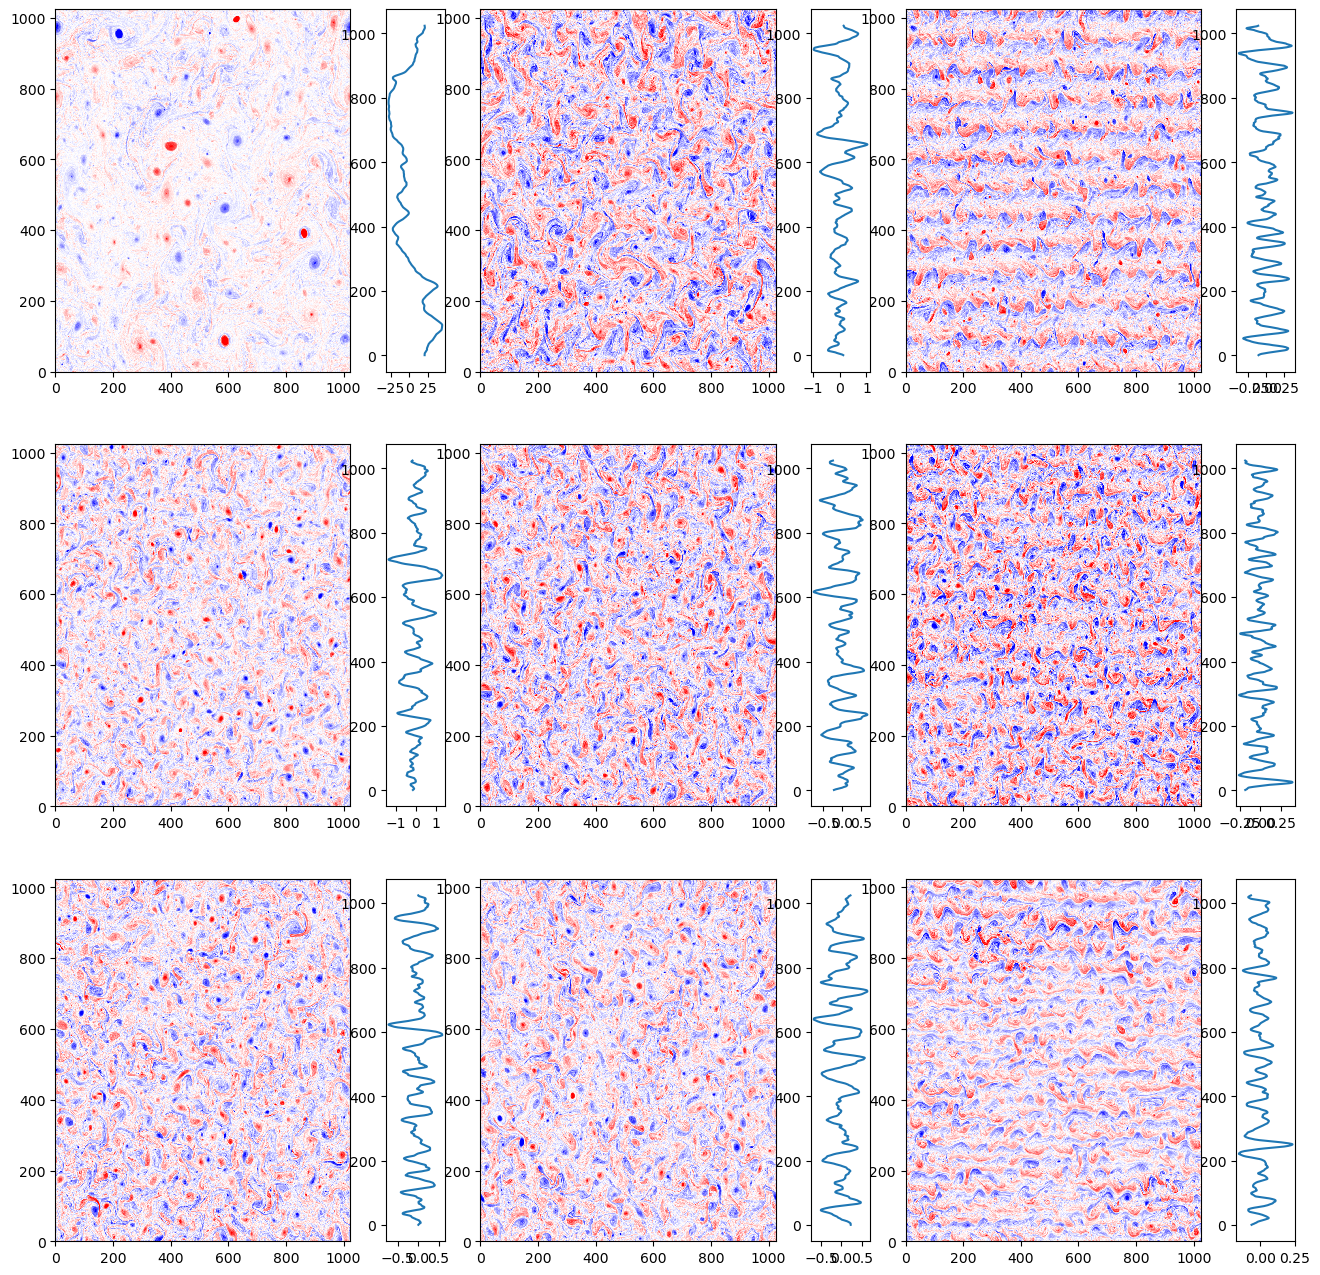

In [231]:
# Late-time snapsots of vorticity
fig, ax = plt.subplots(3,6, figsize=(16,16), width_ratios=[1,0.2,1,0.2,1.,0.2])

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)



a = load(data_dir*jld_name(model_params,62.95))
ψ = a["jld_data"]["psi_yrs_end"]

grid = prob.grid
        
# assigning basic variables
ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])

ψBCh = deepcopy(vars.uh[:,:,1])
ψBTh = deepcopy(vars.uh[:,:,1])

mul2D!(ψBCh, rfftplan, ψBC)
mul2D!(ψBTh, rfftplan, ψBT)

ζBCh = - grid.Krsq .* ψBCh
ζBTh = - grid.Krsq .* ψBTh

ζBC = deepcopy(vars.u[:,:,1])
ζBT = deepcopy(vars.u[:,:,1])

ldiv2D!(ζBC, rfftplan, ζBCh)
ldiv2D!(ζBT, rfftplan, ζBTh)

betas_zeta = [betas[7], betas[9], betas[11]]
mus_zeta = [mus[2], mus[4], mus[6]]

n=1

for i in range(1,3)
    for j in range(1,3)
        h0 = (0.0, 0.0)
        kappa_loc = kappas[1]
        mu_loc = mus_zeta[j]  

        if i==1
            beta = 0.
            global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
            
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
            global topo_PV, eta = define_topo(model_params)
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

        elseif i==2
            h0 = (h0s[10], 0.0)
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
            global topo_PV, eta = define_topo(model_params)
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
    
        elseif i==3
            h0 = (0.0, 0.0)
            beta = betas[10]
            global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)

            global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        end

        a = load(data_dir*jld_name(model_params,62.95))
        ψ = a["jld_data"]["psi_yrs_end"]
        
        grid = prob.grid
                
        # assigning basic variables
        ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
        ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])
        
        ψBCh = deepcopy(vars.uh[:,:,1])
        ψBTh = deepcopy(vars.uh[:,:,1])
        
        mul2D!(ψBCh, rfftplan, ψBC)
        mul2D!(ψBTh, rfftplan, ψBT)
        
        ζBCh = - grid.Krsq .* ψBCh
        ζBTh = - grid.Krsq .* ψBTh
        
        ζBC = deepcopy(vars.u[:,:,1])
        ζBT = deepcopy(vars.u[:,:,1])
        
        ldiv2D!(ζBC, rfftplan, ζBCh)
        ldiv2D!(ζBT, rfftplan, ζBTh)

        UBT = deepcopy(vars.u[:,:,1])
        ldiv2D!(UBT, rfftplan, grid.kr .* ψBTh)
    
        
        norm = (a["jld_data"]["two_layer_vBT_scale"] / Ld)^-1
        lim = maximum(abs.(ζBT .* norm))/2
        
        ax[n].pcolormesh((ζBT .* norm)', cmap=PyPlot.cm.bwr, vmin=-lim, vmax=lim)
        ax[n+3].plot(mean(UBT ./ 0.01, dims=2), collect(range(1,size(ζBT)[1])))

        if mod(n,3)==0
            n+=4
        else
            n+=1
        end
        
    end
end


# kappas = @. κstars / Ld
# mus = @. μstars * ((U[1]-U[end]) / 2) / Ld


# for i in range(1,length(h0s))
#     global h0 = (h0s[i], 0.)
#     for j in range(1, length(kappas))
#         kappa_loc = kappas[j]
#         for k in range(1, length(mus))
#             mu_loc = mus[k]

#             global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#             global topo_PV, eta = define_topo(model_params)
#             global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#             file1 = jld_name(model_params,1)
#             files = glob(file1[2:findfirst("yr",file1)[2]]*"*", data_dir)
            
#             N_files = round(Int, (length(files)))

#             yr_output = zeros(N_files)
#             for (i, file) in enumerate(files)
#                 yr_output[i] = parse(Float64,file[findfirst("yr",file)[2]+1:findfirst(".jld",file)[1]-1])
#             end
            
#             yr_output = sort(yr_output)

#             kap_str = @sprintf "%.3E" kappa_loc
#             mu_str = @sprintf "%.3E" mu_loc
#             h_str = "_" * topo_type * "_h0_" * (@sprintf "%.3E" h0[1])

#             if isempty(yr_output)
#                 println(kap_str * mu_str * h_str * ": " * string(0.0))
#             else
#                 println(kap_str * mu_str * h_str * ":  " * string(yr_output[end]))
#             end
#         end
#     end
# end




# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid




12-element Vector{Int64}:
  1
  2
  3
  4
  5
  6
  8
  9
 10
 11
 12
  7

plot_info_box (generic function with 1 method)

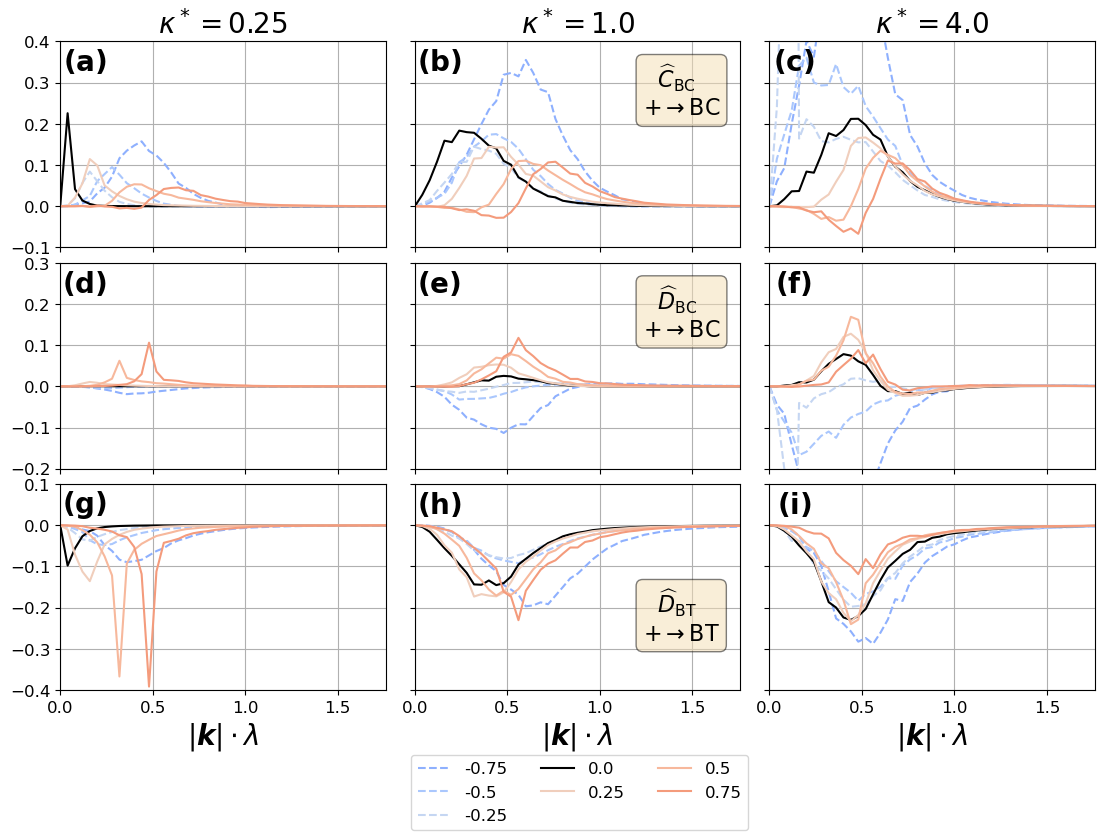

In [51]:

# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(3,3,figsize=(10.5, 6.5))
fig.tight_layout(pad=-1.0)

# h_ind=17
xmax_ind = 45
x = grid.kr .* Ld

fsize = 20
bsize = 16
lsize = 12


####################################################################

####################################################################

for b_ind in collect(range(4,10)) # length(h0s))
    if b_ind<7
        lt = "dashed"
    elseif b_ind>=7
        lt="solid"
    end

    h0 = (0.0, 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[2]
    beta = betas[b_ind]

    # for kappa* = 0.25
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        
    a = load(data_dir*jld_name(model_params,62.95))

    ax[1].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)
    
    ax[2].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[3].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    

    # for kappa* = 1.0
    mu_loc = mus[4]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        
    a = load(data_dir*jld_name(model_params,62.95))

    ax[4].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[5].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[6].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    # for kappa* = 4.0
    mu_loc = mus[6]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        
    a = load(data_dir*jld_name(model_params,62.95))

    ax[7].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[8].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[9].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,7] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(betas[b_ind] / ((U[1]/2) * Ld^-2), sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)


    GC.gc()
end


####################################################################################
ax[1].set_xticklabels([])
ax[2].set_xticklabels([])
ax[4].set_xticklabels([])
ax[5].set_xticklabels([])
ax[7].set_xticklabels([])
ax[8].set_xticklabels([])

ax[4].set_yticklabels([])
ax[5].set_yticklabels([])
ax[6].set_yticklabels([])
ax[7].set_yticklabels([])
ax[8].set_yticklabels([])
ax[9].set_yticklabels([])

ax[6].legend(fontsize=lsize, bbox_to_anchor=(1.05,-0.275), ncol=3)


ax[1].set_title(L"\kappa^* = 0.25", fontsize=fsize)
ax[4].set_title(L"\kappa^* = 1.0", fontsize=fsize)
ax[7].set_title(L"\kappa^* = 4.0", fontsize=fsize)

ax[3].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[6].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[9].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)


# ax3.set_ylim(ax3.get_ylim()[1],1.2)

ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);


ymins = [-0.1, -0.2, -0.4]
ymaxes = ymins .+ 0.5

for i in range(1,length(ax))
    
    axn = ax[i]
    axn.grid()
    axn.tick_params(labelsize=lsize)
    axn.set_xlim(x[1], x[xmax_ind])
    
end


for i in range(1,size(ax)[1])
    # ymax = maximum([ax[i].get_ylim()[2], ax[i+size(ax)[1]].get_ylim()[2]])
    # ymin = minimum([ax[i].get_ylim()[1], ax[i+size(ax)[1]].get_ylim()[1]])

    # ax[i].set_ylim(ymin, ymax)
    # ax[i+size(ax)[1]].set_ylim(ymin, ymax)

    ax[i].set_ylim(ymins[i], ymaxes[i])
    ax[i+size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
    ax[i+2*size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
end

# ax[3].set_ylim(ax[3].get_ylim()[1], ax[3].get_ylim()[2]+0.2)
# ax[6].set_ylim(ax[6].get_ylim()[1], ax[6].get_ylim()[2]+0.2)



###################################################################
###################################################################

plot_info_box(ax[4], L"\ \ \widehat{C}_\mathrm{BC}", 0.7, 0.9, "BC", bsize)
plot_info_box(ax[5], L"\ \ \widehat{D}_\mathrm{BC}", 0.7, 0.9, "BC", bsize)
plot_info_box(ax[6], L"\ \ \widehat{D}_\mathrm{BT}", 0.7, 0.5, "BT", bsize)


# savefig("./drag_figs/beta_SS_kspace.pdf",bbox_inches="tight", transparent=true)



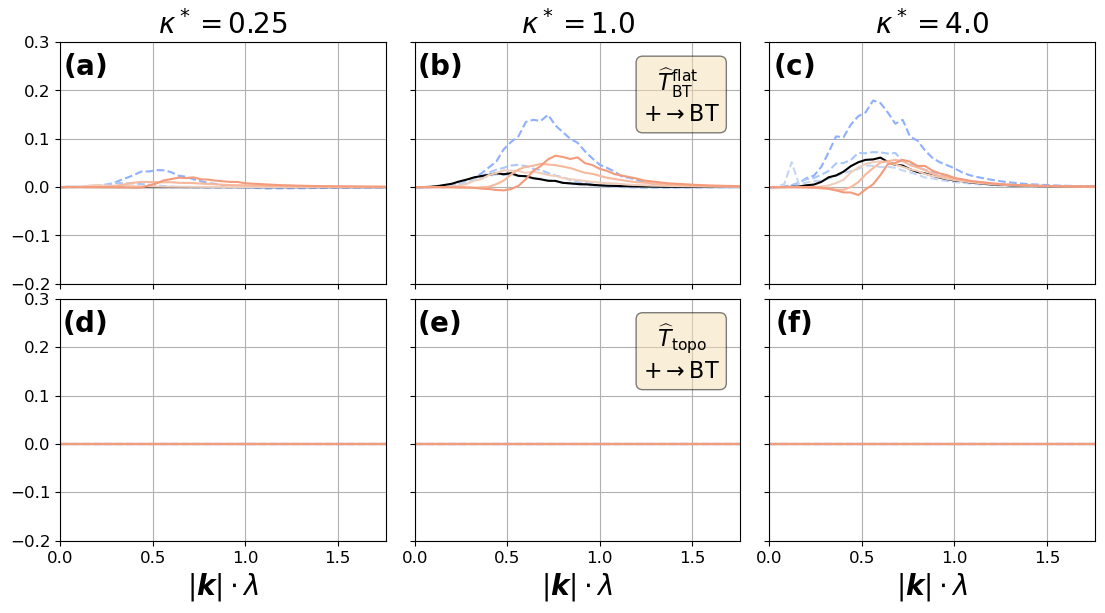

In [53]:

# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(2,3,figsize=(10.5,5))
fig.tight_layout(pad=-1.0)

# b_ind=17

xmax_ind = 45
x = grid.kr .* Ld

fsize = 20
bsize = 16
lsize = 12

# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBCEKE (13) NLBCEAPE (14) resid

####################################################################

####################################################################

for b_ind in collect(range(4,10)) # length(h0s))
    if b_ind<7
        lt = "dashed"
    elseif b_ind>=7
        lt="solid"
    end

    h0 = (0.0, 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[2]
    beta = betas[b_ind]

    # for kappa* = 0.25
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name(model_params,62.95))
    
    ax[1].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[2].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    
    # for kappa* = 1.0
    mu_loc = mus[4]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        
    a = load(data_dir*jld_name(model_params,62.95))
    
    ax[3].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[4].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)


    # kappa* = 4.0
    mu_loc = mus[6]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name(model_params,62.95))

    ax[5].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[6].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)
    
    GC.gc()
end

for i in range(1,length(ax))
    
    axn = ax[i]
    axn.grid()
    axn.tick_params(labelsize=lsize)
    axn.set_xlim(x[1], x[xmax_ind])
    
end



####################################################################################

ax[1].set_xticklabels([])
ax[3].set_xticklabels([])
ax[5].set_xticklabels([])

ax[3].set_yticklabels([])
ax[4].set_yticklabels([])
ax[5].set_yticklabels([])
ax[6].set_yticklabels([])


# ax[4].legend(fontsize=lsize, bbox_to_anchor=(1.8,-0.275), ncol=3)


ax[1].set_title(L"\kappa^* = 0.25", fontsize=fsize)
ax[3].set_title(L"\kappa^* = 1.0", fontsize=fsize)
ax[5].set_title(L"\kappa^* = 4.0", fontsize=fsize)

ax[2].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[4].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[6].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);


ymins = [-0.2, -0.2]
ymaxes = ymins .+ 0.5

for i in range(1,size(ax)[1])
    # ymax = maximum([ax[i].get_ylim()[2], ax[i+size(ax)[1]].get_ylim()[2]])
    # ymin = minimum([ax[i].get_ylim()[1], ax[i+size(ax)[1]].get_ylim()[1]])

    # ax[i].set_ylim(ymin, ymax)
    # ax[i+size(ax)[1]].set_ylim(ymin, ymax)

    ax[i].set_ylim(ymins[i], ymaxes[i])
    ax[i+size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
    ax[i+2*size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
end

###################################################################
###################################################################

plot_info_box(ax[3], L"\ \ \widehat{T}^\mathrm{flat}_\mathrm{BT}", 0.7, 0.9, "BT", bsize)
plot_info_box(ax[4], L"\ \ \widehat{T}_\mathrm{topo}", 0.7, 0.9, "BT", bsize)

# savefig("./drag_figs/beta_LF_kspace.pdf",bbox_inches="tight", transparent=true)


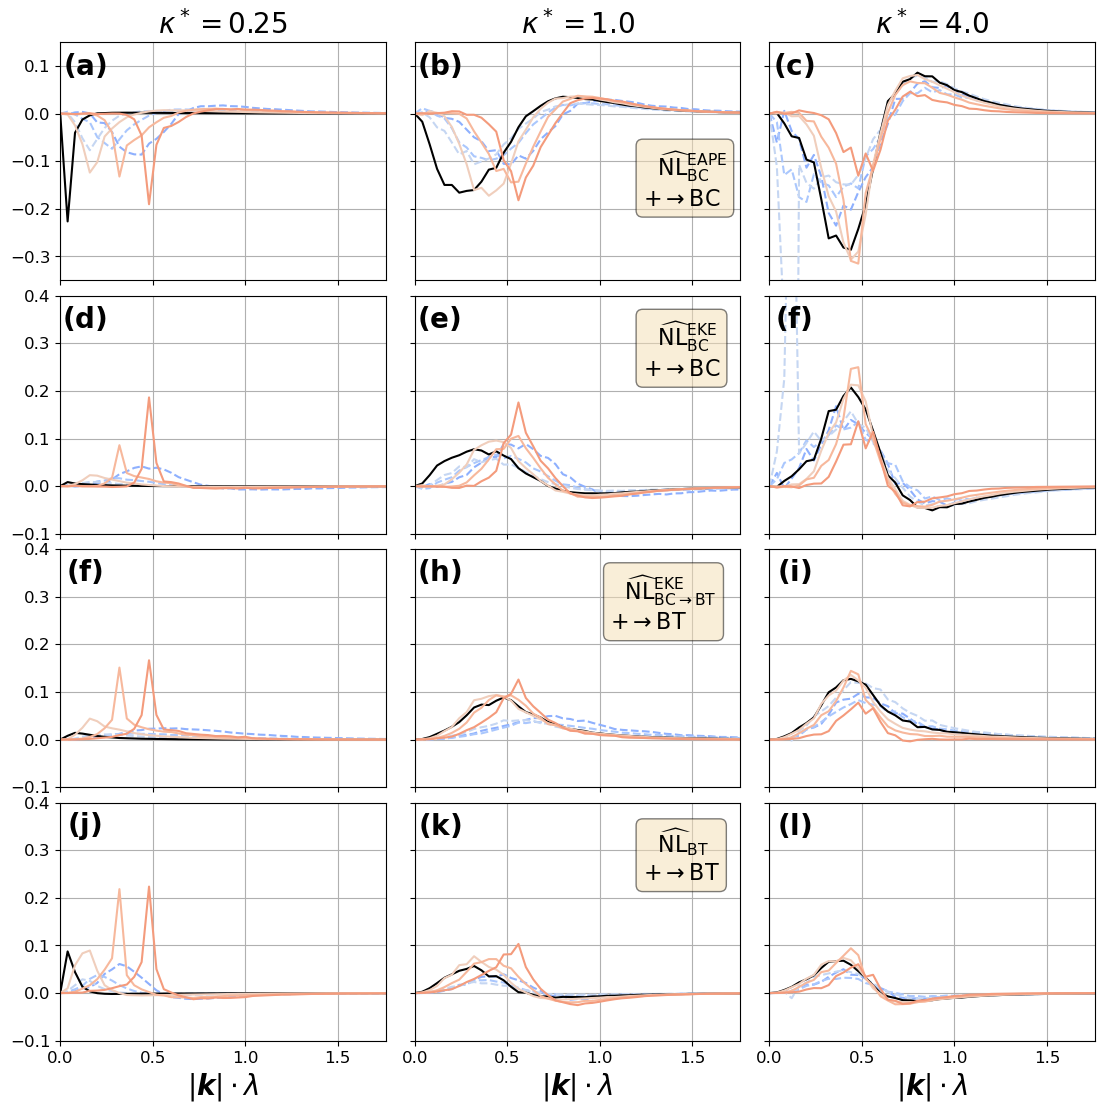

In [39]:

# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(4,3,figsize=(10.5,10))
fig.tight_layout(pad=-1.0)

xmax_ind = 45

x = grid.kr .* Ld

fsize = 20
bsize=16
lsize = 12

# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBTEKE, (10) NLBC2BT , (11) NLBT2BC; (12) NLBCEKE (13) NLBCEAPE (14) resid

####################################################################

####################################################################


for b_ind in collect(range(4,10)) # length(h0s))
    if b_ind<7
        lt = "dashed"
    elseif b_ind>=7
        lt="solid"
    end

    h0 = (0.0, 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[2]
    beta = betas[b_ind]

    # for kappa* = 0.25
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
        
    a = load(data_dir*jld_name(model_params,62.95))
    
    ax[1].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[2].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    # ax[3].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)
    ax[3].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[4].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)


    # for kappa* = 1.0
    mu_loc = mus[4]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
     
    a = load(data_dir*jld_name(model_params,62.95))
    
    ax[5].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[6].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    # ax[7].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)
    ax[7].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[8].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    # for kappa* = 4.0
    mu_loc = mus[6]
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
     
    a = load(data_dir*jld_name(model_params,62.95))

    ax[9].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[10].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    # ax[11].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)
    ax[11].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    ax[12].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld), label=string(round(h0s[b_ind] / S32, sigdigits=3)), color=h_color(h0s[b_ind],hc_range,colors),linestyle=lt)

    GC.gc()
end

for i in range(1,length(ax))
    
    axn = ax[i]
    axn.grid()
    axn.tick_params(labelsize=lsize)
    axn.set_xlim(x[1], x[xmax_ind])
    
end


####################################################################################
ax[1].set_xticklabels([])
ax[2].set_xticklabels([])
ax[3].set_xticklabels([])
ax[5].set_xticklabels([])
ax[6].set_xticklabels([])
ax[7].set_xticklabels([])
ax[9].set_xticklabels([])
ax[10].set_xticklabels([])
ax[11].set_xticklabels([])

ax[5].set_yticklabels([])
ax[6].set_yticklabels([])
ax[7].set_yticklabels([])
ax[8].set_yticklabels([])

ax[9].set_yticklabels([])
ax[10].set_yticklabels([])
ax[11].set_yticklabels([])
ax[12].set_yticklabels([])


# ax[4].legend(fontsize=lsize, bbox_to_anchor=(1.8,-0.275), ncol=3)


ax[1].set_title(L"\kappa^* = 0.25", fontsize=fsize)
ax[5].set_title(L"\kappa^* = 1.0", fontsize=fsize)
ax[9].set_title(L"\kappa^* = 4.0", fontsize=fsize)

ax[4].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[8].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[12].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)


ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(j)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
ax[7].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
ax[8].text(0.075, 0.9, L"\mathbf{(k)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
ax[9].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);
ax[10].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[10].transAxes);
ax[11].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[11].transAxes);
ax[12].text(0.075, 0.9, L"\mathbf{(l)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[12].transAxes);


ymins = [-0.35, -0.1, -0.1, -0.1]
ymaxes = ymins .+ 0.5

for i in range(1,size(ax)[1])
    # ymax = maximum([ax[i].get_ylim()[2], ax[i+size(ax)[1]].get_ylim()[2]])
    # ymin = minimum([ax[i].get_ylim()[1], ax[i+size(ax)[1]].get_ylim()[1]])

    # ax[i].set_ylim(ymin, ymax)
    # ax[i+size(ax)[1]].set_ylim(ymin, ymax)

    ax[i].set_ylim(ymins[i], ymaxes[i])
    ax[i+size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
    ax[i+2*size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
end
# ax4.set_yscale("symlog")

######################################################################################
######################################################################################

plot_info_box(ax[5], L"\ \ \widehat{\mathrm{NL}}^\mathrm{EAPE}_\mathrm{BC}", 0.7, 0.55, "BC", bsize)
plot_info_box(ax[6], L"\ \ \widehat{\mathrm{NL}}^\mathrm{EKE}_\mathrm{BC}", 0.7, 0.9, "BC", bsize)
plot_info_box(ax[7], L"\ \ \widehat{\mathrm{NL}}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", 0.6, 0.9, "BT", bsize)
plot_info_box(ax[8], L"\ \ \widehat{\mathrm{NL}}_\mathrm{BT}", 0.7, 0.9, "BT", bsize)



# savefig("./drag_figs/beta_NL_kspace.pdf",bbox_inches="tight", transparent=true)


# negative phase shifts for the positive slopes at large wavenumbers corresponds
# to the slight forward cascade seen in their spectra

# will we see same thing for flat-bottom as drag is varied?

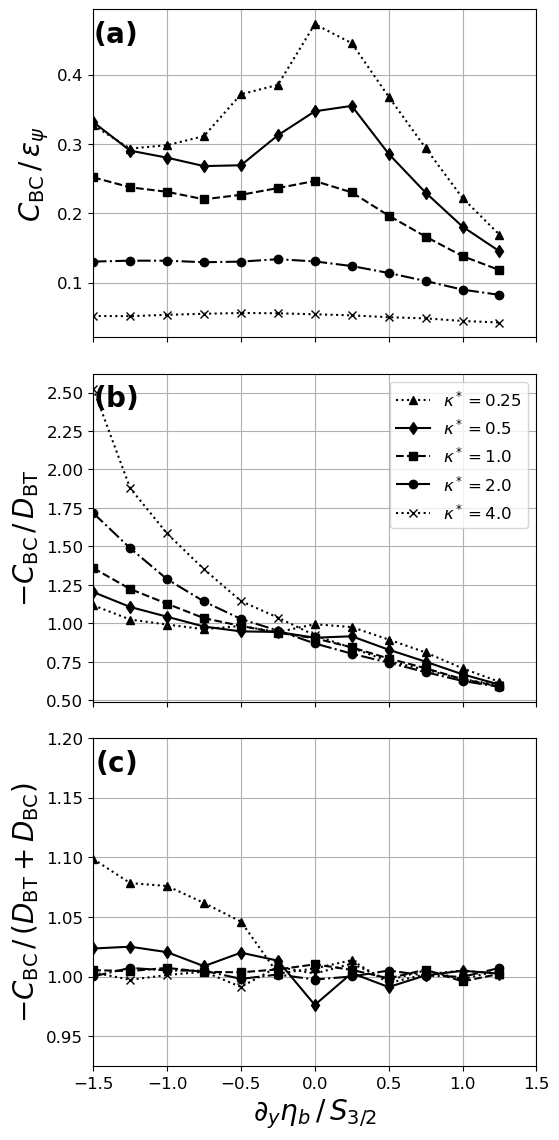

In [25]:
fig, ax = plt.subplots(3,1, figsize=(5,11))
fig.tight_layout(pad=0.5)

ax1=ax[1]; ax2=ax[2]; ax3=ax[3]

lsize = 20
tsize = 12

x = h0s ./ S32
x2 = x[7:end-1]

# BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

function define_source_sink_ratios(mu_loc)

    CBC_over_eps_psi = zeros(length(h0s)) .* NaN
    CBC_over_DBT = zeros(length(h0s)) .* NaN
    CBC_over_drag_tot = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, 12) # length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)

        CBC_over_eps_psi[h_ind] = xmn[6] / (2 * mu_loc * xmn[1])  # CBC/ eps_psi
    
        CBC_over_DBT[h_ind] = -xmn[6] / xmn[8]          # -CBC / DBT
    
        CBC_over_drag_tot[h_ind] = - xmn[6] / (xmn[8] + xmn[9])  # -CBC / (DBT+DBC)

    end
        
    return CBC_over_eps_psi, CBC_over_DBT, CBC_over_drag_tot
end

CBC_over_eps_psi_mu1, CBC_over_DBT_mu1, CBC_over_drag_tot_mu1 = define_source_sink_ratios(mus[1])

CBC_over_eps_psi_mu2, CBC_over_DBT_mu2, CBC_over_drag_tot_mu2 = define_source_sink_ratios(mus[2])

CBC_over_eps_psi_mu3, CBC_over_DBT_mu3, CBC_over_drag_tot_mu3 = define_source_sink_ratios(mus[3])

CBC_over_eps_psi_mu4, CBC_over_DBT_mu4, CBC_over_drag_tot_mu4 = define_source_sink_ratios(mus[4])

CBC_over_eps_psi_mu5, CBC_over_DBT_mu5, CBC_over_drag_tot_mu5 = define_source_sink_ratios(mus[5])


# for i in range(1,length(ax))
    
#     axn = ax[i]
#     axn.grid()
#     axn.tick_params(labelsize=lsize)
#     axn.set_xlim(x[1], x[end])
    
# end

#########################################################################################################
## 
#########################################################################################################

# ax1.plot(x2, BC_nu0_kap0p125[1:end-1] ./ (kappas_dim[1] * BTEKE_nu0_kap0p125[1:end-1] .* 2), color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax1.plot(x, CBC_over_eps_psi_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax1.plot(x, CBC_over_eps_psi_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, CBC_over_eps_psi_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, CBC_over_eps_psi_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, CBC_over_eps_psi_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax1.set_ylabel(L" C_\mathrm{BC} \, / \, \epsilon_{\psi} ", fontsize=lsize)
# ax1.set_xlabel(L"\partial_y \eta_b \, / \, S_{3/2} ", fontsize=lsize)


# ax1.set_yscale("log")

ax1.set_xlim(x[1], x[end])
ax1.grid()


#########################################################################################################
## 
#########################################################################################################
# ax2.plot(x2, BC_nu0_kap0p125[1:end-1] ./ (kappas_dim[1] * BTEKE_nu0_kap0p125[1:end-1] .* 2), color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax2.plot(x, CBC_over_DBT_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax2.plot(x, CBC_over_DBT_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, CBC_over_DBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax2.plot(x, CBC_over_DBT_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x, CBC_over_DBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax2.set_ylabel(L"-  C_\mathrm{BC} \, / \, D_\mathrm{BT}", fontsize=lsize)
# ax2.set_xlabel(L"\partial_y \eta_b \, / \, S_{3/2} ", fontsize=lsize)

ax2.set_xlim(x[1], x[end])
ax2.grid()


#########################################################################################################
## 
#########################################################################################################
# ax3.plot(x2, BC_nu0_kap0p125[1:end-1] ./ (kappas_dim[1] * BTEKE_nu0_kap0p125[1:end-1] .* 2), color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax3.plot(x, CBC_over_drag_tot_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax3.plot(x, CBC_over_drag_tot_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax3.plot(x, CBC_over_drag_tot_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax3.plot(x, CBC_over_drag_tot_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax3.plot(x, CBC_over_drag_tot_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax3.set_xlim(x[1], x[end])
ax3.grid()
ax3.set_ylabel(L"- C_\mathrm{BC} \, / \, \left ( D_\mathrm{BT}  + D_\mathrm{BC} \right ) ", fontsize=lsize)
ax3.set_xlabel(L"\partial_y \eta_b \, / \, S_{3/2} ", fontsize=lsize)

ax3.set_ylim(0.925, 1.2)
#########################################################################################################
## 
#########################################################################################################


ax1.text(0.05, 0.925, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.05, 0.925, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.05, 0.925, L"\mathbf{(c)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);

ax2.legend(fontsize=tsize)


ax1.tick_params(labelsize=tsize)
ax2.tick_params(labelsize=tsize)
ax3.tick_params(labelsize=tsize)

ax1.set_xticklabels([])
ax2.set_xticklabels([]);



# savefig("./drag_figs/source_sink_ratios.pdf",bbox_inches="tight")



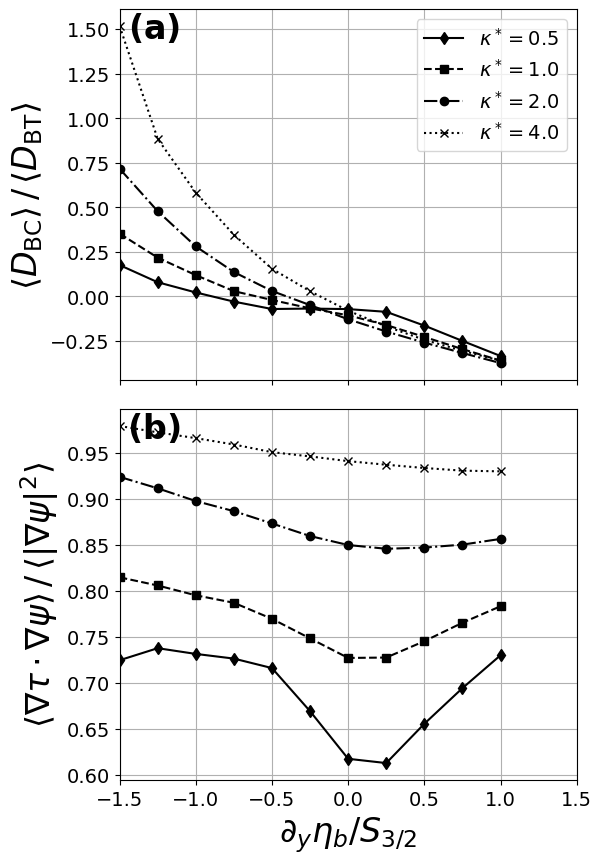

In [12]:
fig, ax = plt.subplots(2,1,figsize=(5,8))
fig.tight_layout(pad=0.0)
ax1=ax[1]; ax2=ax[2]

lsize = 24
tsize = 14

x = h0s ./ S32
x2 = x[7:end]


# (1) BTKE_x, (2) BCKE_x, (3) BCEAPE_x, (4) LT_x, (5) TT_x, (6) BC_x, (7) NL_x, (8) DBT_x, (9) DBC_x, (10) resid_x

function define_sink_ratios(mu_loc)

    DBC_over_DBT = zeros(length(h0s)) .* NaN
    CI_over_2BT_EKE = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, 11) # length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)
    
        DBC_over_DBT[h_ind] = xmn[9] / xmn[8]          # 
    
        CI_over_2BT_EKE[h_ind] = ((xmn[8] + 2 * mu_loc * xmn[1]) / mu_loc ) / (2 * xmn[1])  # 

    end
        
    return DBC_over_DBT, CI_over_2BT_EKE
end

DBC_over_DBT_mu2, CI_over_2BT_EKE_mu2 = define_sink_ratios(mus[2])

DBC_over_DBT_mu3, CI_over_2BT_EKE_mu3 = define_sink_ratios(mus[3])

DBC_over_DBT_mu4, CI_over_2BT_EKE_mu4 = define_sink_ratios(mus[4])

DBC_over_DBT_mu5, CI_over_2BT_EKE_mu5 = define_sink_ratios(mus[5])


# for i in range(1,length(ax))
    
#     axn = ax[i]
#     axn.grid()
#     axn.tick_params(labelsize=lsize)
#     axn.set_xlim(x[1], x[end])
    
# end

#########################################################################################################
## 
#########################################################################################################

# ax1.plot(x2, BC_nu0_kap0p125[1:end-1] ./ (kappas_dim[1] * BTEKE_nu0_kap0p125[1:end-1] .* 2), color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x[4:end], BC_nu0_kap0p25[4:end] ./ (kappas_dim[2] * BTEKE_nu0_kap0p25[4:end] .* 2), color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax1.plot(x, DBC_over_DBT_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, DBC_over_DBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, DBC_over_DBT_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, DBC_over_DBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

#########################################################################################################
## 
#########################################################################################################
# ax2.plot(x2, BC_nu0_kap0p125[1:end-1] ./ (kappas_dim[1] * BTEKE_nu0_kap0p125[1:end-1] .* 2), color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], BC_nu0_kap0p25[4:end] ./ (kappas_dim[2] * BTEKE_nu0_kap0p25[4:end] .* 2), color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax2.plot(x, CI_over_2BT_EKE_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, CI_over_2BT_EKE_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax2.plot(x, CI_over_2BT_EKE_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x, CI_over_2BT_EKE_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

#########################################################################################################
## 
#########################################################################################################

#######################################################################################################

ax1.set_xlim(x[1], x[end])
ax1.tick_params(labelsize=tsize)
# ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
ax1.grid()
ax1.set_ylabel(L"\langle D_\mathrm{BC} \rangle \,  / \, \langle D_\mathrm{BT} \rangle", fontsize=lsize)



ax2.set_xlim(x[1], x[end])
ax2.tick_params(labelsize=tsize)
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
ax2.grid()
ax2.set_ylabel(L"\langle \nabla \tau \cdot \nabla \psi \rangle \,  / \, \langle | \nabla \psi | ^2 \rangle", fontsize=lsize)

# ax2.text(-0.15, 0.5, L"\langle D_\mathrm{BC} \rangle \,  / \, \langle D_\mathrm{BT} \rangle", fontsize=lsize, rotation=90, 
#             verticalalignment="center", horizontalalignment="right", 
#             transform=ax2.transAxes)


ax1.legend(fontsize=tsize) # , bbox_to_anchor=(0.525, 0.4)) #,loc="upper left")

# ax1.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
ax1.set_xticklabels([])

# ax1.set_ylim(-0.5,1.75)
# ax2.set_ylim(0.0,1.1)

# ax1.set_yscale("log")


ax1.text(0.075, 0.95, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.075, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
# ax3.text(0.075, 0.95, L"\mathbf{(c)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);

#######################################################################################################

# savefig("./drag_figs/cross_inv_assumptions.pdf",bbox_inches="tight")



In [13]:
function int_IC_pos(NL)
    # NL is EKE inverse cascade term for BT or BC mode
    term_sign = NL[1:end-1] .* NL[2:end]
        ind = findall(x->x<0, term_sign)
    if ind[1]<10
        if ind[2]<10
            if ind[3]<10
                is = ind[4]
            else
                is = ind[3]
            end
        else
            is = ind[2]
        end
    else
        is = ind[1]
    end
    return sum(NL[1:is])
end


DC_ratio_kap0p125 = zeros(length(h0s[7:end]))
DC_ratio_kap0p25 = zeros(length(h0s))
DC_ratio_kap0p5 = zeros(length(h0s))
DC_ratio_kap1   = zeros(length(h0s))
DC_ratio_kap2   = zeros(length(h0s))
DC_ratio_kap4   = zeros(length(h0s))

# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBTEKE, (10) NLBC2BT , (11) NLBT2BC; (12) NLBCEKE (13) NLBCEAPE (14) resid

for i in range(1, 11) #length(h0s))
    # if i>6
    #     DC_ratio_kap0p125[i-6] = int_IC_pos(NLBC_nu0_kap0p125[:,i-6,2]) / int_IC_pos(NLBT_nu0_kap0p125[:,i-6,1])
    # end

    h0 = (h0s[i], 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[1]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)


    # kappa* = 0.5
    mu_loc = mus[2]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))

    DC_ratio_kap0p5[i]   = int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12]) / int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9])

    # kappa* = 1.0
    mu_loc = mus[3]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))

    DC_ratio_kap1[i]   = int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12]) / int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9])

    # kappa* = 2.0
    mu_loc = mus[4]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))
    
    DC_ratio_kap2[i]   = int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12]) / int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9])
    
    
    # kappa* = 4.0
    mu_loc = mus[5]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))
    
    DC_ratio_kap4[i]   = int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12]) / int_IC_pos(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9])
    
end






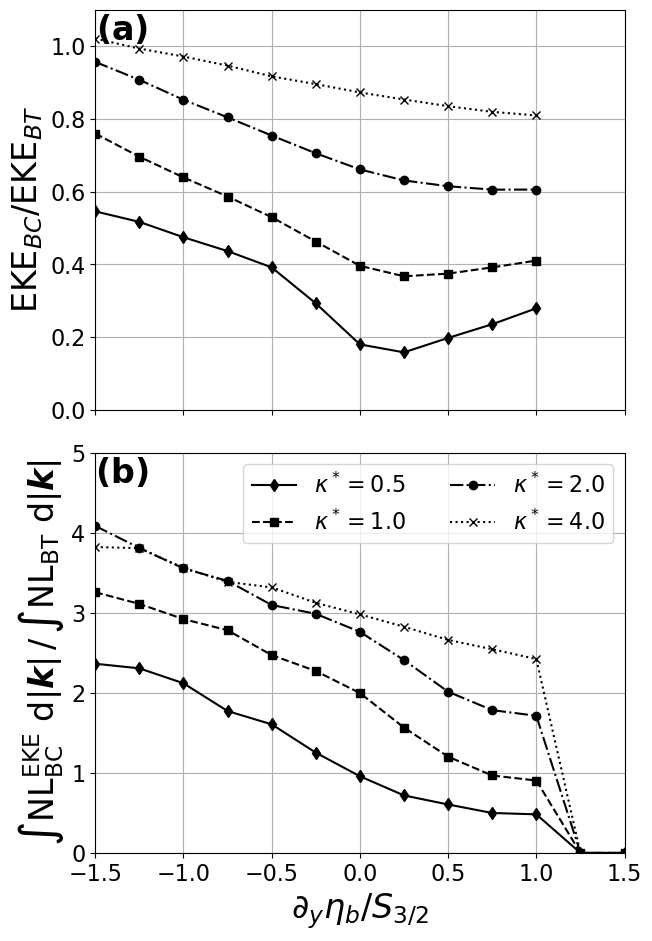

In [14]:
# fig, ax = plt.subplots(3,1, figsize=(6,13.5))
fig, ax = plt.subplots(2,1, figsize=(6,9))

fig.tight_layout(pad=1.0)

ax1=ax[1]; ax2=ax[2]; # ax3=ax[3];

lsize = 24
tsize = 16

x = h0s ./ S32
x2 = x[7:end-1]


# BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

function define_modal_nrg_ratios(mu_loc)

    EKEBC_over_EKEBT = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, 11) # length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)
    
        EKEBC_over_EKEBT[h_ind] = xmn[2] / xmn[1]          # 
    
    end
        
    return EKEBC_over_EKEBT
end

EKEBC_over_EKEBT_mu2 = define_modal_nrg_ratios(mus[2])

EKEBC_over_EKEBT_mu3 = define_modal_nrg_ratios(mus[3])

EKEBC_over_EKEBT_mu4 = define_modal_nrg_ratios(mus[4])

EKEBC_over_EKEBT_mu5 = define_modal_nrg_ratios(mus[5])


############################################################################
# ax1.plot(x2, BCEKE_nu0_kap0p125[1:end-1] ./ BTEKE_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x[4:end], BCEKE_nu0_kap0p25[4:end] ./ BTEKE_nu0_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax1.plot(x, EKEBC_over_EKEBT_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, EKEBC_over_EKEBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, EKEBC_over_EKEBT_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, EKEBC_over_EKEBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax1.plot(x, BCEKE_nu0_mu1 ./ BTEKE_nu0_mu1, color="r", marker="x", linestyle="--", label=L"\mu^* = 1.0")

ax1.set_ylabel(L" \mathrm{EKE}_{BC} /  \mathrm{EKE}_{BT} ", fontsize=lsize)

ax1.set_xlim(x[1], x[end])
# ax1.set_ylim(ax1.get_ylim()[1], 1.3)  # minimum(BCEKE_nu0_kap0p25 ./ BTEKE_nu0_kap0p25), 1.3) # 
ax1.set_ylim(0.0, 1.1)

ax1.set_xticklabels([])
# ax1.set_yscale("log")

ax1.tick_params(labelsize=tsize, which="both")

# ax1.legend(fontsize=tsize)

ax1.grid()



############################################################################
# # ax2.plot(x2, BTEKE_nu0_kap0p125, color="k", marker="^", linestyle="--", label=L"\kappa^* = 0.125")
# ax2.plot(x, BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax2.plot(x, BTEKE_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, BTEKE_nu0_kap2, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
# ax2.plot(x, BTEKE_nu0_kap4, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax2.set_ylabel(L"\langle \mathrm{EKE}_{BT} \rangle \ \ [ \mathrm{m}^2 \mathrm{s}^{-2} ]", fontsize=lsize)
# # ax2.set_xticklabels([])


# ax2.set_xlim(x[1], x[end])

# ax2.set_yscale("log")

# ax2.tick_params(labelsize=tsize, which="both")
# ax2.grid()


# ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

############################################################################

# ax2.plot(x2, DC_ratio_kap0p125[1:end-1], color="k", marker=".", linestyle="-.",      label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], DC_ratio_kap0p25[4:end],   color="k", marker="^", linestyle="dotted",     label=L"\kappa^* = 0.25")
ax2.plot(x, DC_ratio_kap0p5, color="k", marker="d", linestyle="-",      label=L"\kappa^* = 0.5")
ax2.plot(x, DC_ratio_kap1,   color="k", marker="s", linestyle="--",     label=L"\kappa^* = 1.0")
ax2.plot(x, DC_ratio_kap2,   color="k", marker="o", linestyle="-.",     label=L"\kappa^* = 2.0")
ax2.plot(x, DC_ratio_kap4,   color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax2.set_xlim(x[1], x[end])
ax2.grid()

ax2.legend(fontsize=tsize, ncol=2)

ax2.set_ylabel(L"\int \mathrm{NL}_\mathrm{BC}^\mathrm{EKE} \ \mathrm{d} | \boldsymbol{k} | \, / \, \int  \mathrm{NL}_\mathrm{BT} \ \mathrm{d} | \boldsymbol{k} |",fontsize=lsize)
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2} ",fontsize=lsize)
# ax2.set_xticklabels([])

ax2.tick_params(labelsize=tsize, which="both")

ax2.set_ylim(0., 5)


############################################################################
############################################################################


############################################################################
############################################################################

ax1.text(0.05, 0.95, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.05, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);

# savefig("./drag_figs/modal_nrgs.pdf",bbox_inches="tight")




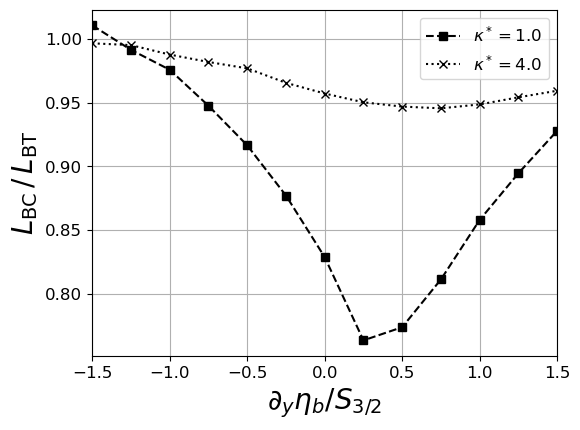

(-1.5, 1.5)

In [13]:
fig, ax2 = plt.subplots(1,1, figsize=(6,4.5))

lsize = 20
tsize = 12

x = h0s ./ S32
x2 = x[7:end-1]

############################################################################

############################################################################
function define_modal_scale_ratios(mu_loc)

    LBC_over_LBT = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))
    
        LBC_over_LBT[h_ind] = a["jld_data"]["two_layer_modal_length_scales"][1] / a["jld_data"]["two_layer_modal_length_scales"][2]
        
    end
        
    return LBC_over_LBT
end

LBC_over_LBT_mu3 = define_modal_scale_ratios(mus[3])

LBC_over_LBT_mu5 = define_modal_scale_ratios(mus[5])



############################################################################

############################################################################

# ax2.plot(x2, LS_nu0_kap0p125[1:end-1,2] ./ LS_nu0_kap0p125[1:end-1,1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], LS_nu0_kap0p25[4:end,2] ./ LS_nu0_kap0p25[4:end,1], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, LS_nu0_kap0p5[:,2] ./ LS_nu0_kap0p5[:,1], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, LBC_over_LBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, LS_nu0_kap2[:,2] ./ LS_nu0_kap2[:,1], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x,LBC_over_LBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax2.set_ylabel(L"L_\mathrm{BC}  \, / \, L_\mathrm{BT} ", fontsize=lsize)
# ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
ax2.legend(fontsize=tsize)
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

ax2.grid()

ax2.tick_params(labelsize=tsize, which="both")

# ax1.set_yscale("log")

ax2.set_xlim(x[1], x[end])





############################################################################

############################################################################

# savefig("./drag_figs/BC_BT_scale_ratio.pdf",bbox_inches="tight")


6-element Vector{Float64}:
 2.2065285161714542e-8
 4.4130570323429084e-8
 8.826114064685817e-8
 1.7652228129371634e-7
 3.5304456258743267e-7
 7.060891251748653e-7

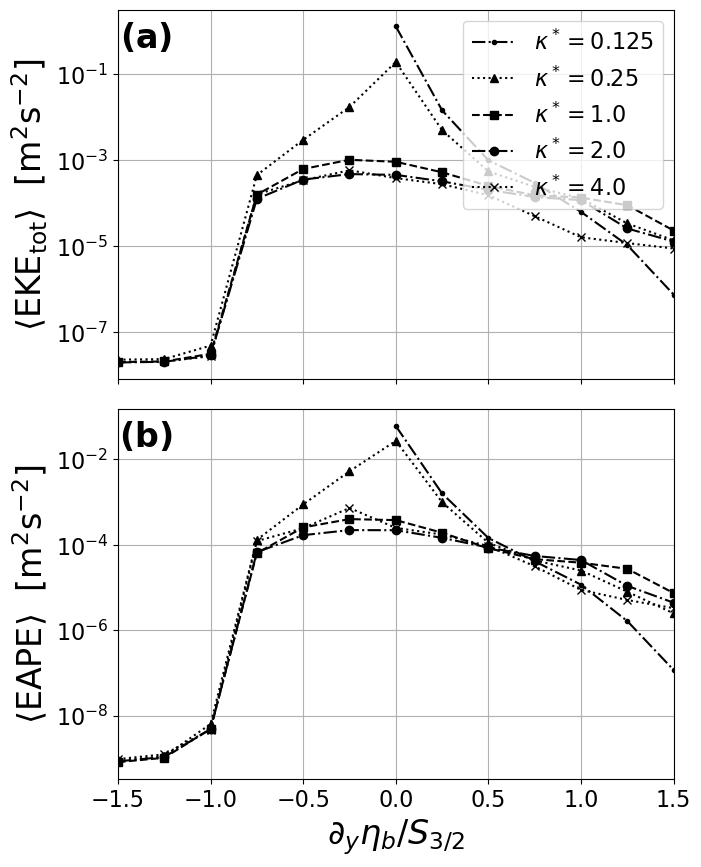

In [16]:

function define_layered_nrgs(mu_loc)

    EKE_tot = zeros(length(betas)) .* NaN
    EAPE = zeros(length(betas)) .* NaN

    if mu_loc == mus[1]
        it_r = collect(range(7,13))
    else
        it_r = collect(range(1,13))
    end
    
    for b_ind in it_r # length(h0s))

        h0 = (0.0, 0.0)
        kappa_loc = kappas[1]
        beta = betas[b_ind]
    
        # for kappa* = 0.25
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)

        global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_nrgs_ot"]  # xspace modal nrgs (xmn)
    
        EKE_tot[b_ind] = mean(xmn[1,:]) + mean(xmn[2,:])          # 

        EAPE[b_ind] = mean(xmn[3,:])
    
    end
        
    return EKE_tot, EAPE
end

EKE_tot_mu0, EAPE_mu0 = define_layered_nrgs(mus[1])

EKE_tot_mu1, EAPE_mu1 = define_layered_nrgs(mus[2])

# EKE_tot_mu2, EAPE_mu2 = define_layered_nrgs(mus[3])

EKE_tot_mu3, EAPE_mu3 = define_layered_nrgs(mus[4])

EKE_tot_mu4, EAPE_mu4 = define_layered_nrgs(mus[5])

EKE_tot_mu5, EAPE_mu5 = define_layered_nrgs(mus[6])


############################################################################
fig, ax = plt.subplots(2,1, figsize=(6,8))
fig.tight_layout(pad=0.05)

ax1=ax[1]; ax3=ax[2]; # ax3=ax[3];

lsize = 24
tsize = 16

x = h0s ./ S32
x2 = x[7:end]

############################################################################
ax1.plot(x, EKE_tot_mu0, color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax1.plot(x, EKE_tot_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x, EKE_tot_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, EKE_tot_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, EKE_tot_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, EKE_tot_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax1.set_ylabel(L"\langle \mathrm{EKE}_\mathrm{tot} \rangle \ \ [ \mathrm{m}^2 \mathrm{s}^{-2} ]", fontsize=lsize)

ax1.set_xlim(x[1], x[end])

ax1.set_xticklabels([])
ax1.tick_params(labelsize=tsize, which="both")


ax1.set_yscale("log")
ax1.grid()

# ############################################################################
# # ax2.plot(x2, EKE12_nu0_kap0p125[:,1] ./ EKE12_nu0_kap0p125[:,2], color="k", marker="^", linestyle="--", label=L"\kappa^* = 0.125")
# ax2.plot(x, EKE12_nu0_kap0p5[:,1] ./ EKE12_nu0_kap0p5[:,2], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax2.plot(x, EKE12_nu0_kap1[:,1] ./ EKE12_nu0_kap1[:,2], color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, EKE12_nu0_kap2[:,1] ./ EKE12_nu0_kap2[:,2], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
# ax2.plot(x, EKE12_nu0_kap4[:,1] ./ EKE12_nu0_kap4[:,2], color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

# ax2.set_ylabel(L"\langle \mathrm{EKE}_{1} \rangle / \langle \mathrm{EKE}_{2} \rangle", fontsize=lsize)
# ax2.set_xticklabels([])


# ax2.set_xlim(x[1], x[end])

# ax2.tick_params(labelsize=tsize, which="both")

# ax2.set_yscale("log")
# ax2.grid()

############################################################################
ax3.plot(x, EAPE_mu0, color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax3.plot(x, EAPE_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax3.plot(x, EAPE_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax3.plot(x, EAPE_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax3.plot(x, EAPE_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax3.plot(x, EAPE_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax3.set_ylabel(L"\langle \mathrm{EAPE} \rangle \ \ [ \mathrm{m}^2 \mathrm{s}^{-2} ]", fontsize=lsize)

ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

ax3.set_xlim(x[1], x[end])

ax3.tick_params(labelsize=tsize, which="both")
ax3.set_yscale("log")
ax3.grid()

############################################################################
ax1.legend(fontsize=tsize, loc="upper right")

ax1.text(0.05, 0.925, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.05, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.05, 0.925, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);

# savefig("./drag_figs/beta_total_nrgs.pdf",bbox_inches="tight")




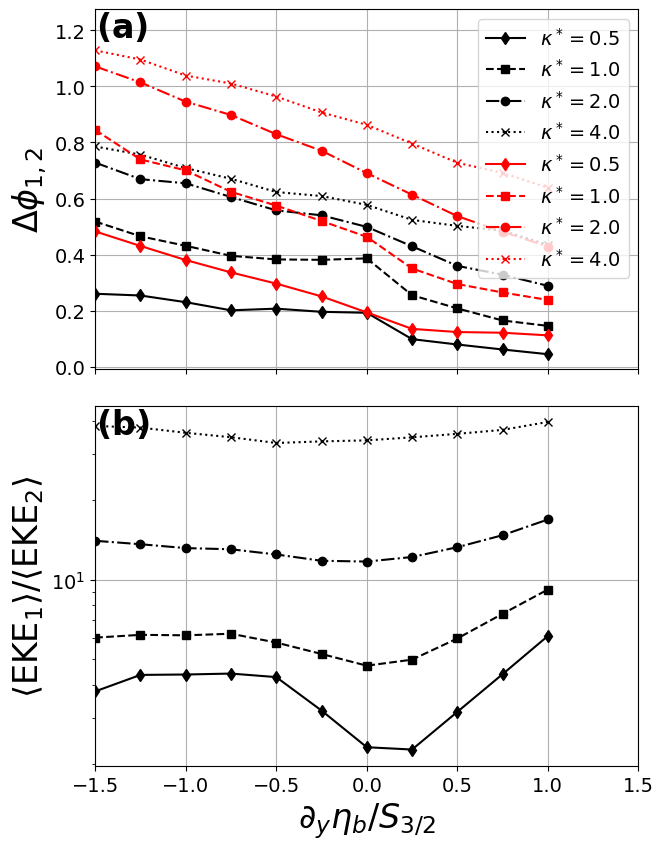

In [16]:

function define_layered_ratio_and_phases(mu_loc)

    EKE1_over_EKE2 = zeros(length(h0s)) .* NaN
    ph_iso = zeros(length(h0s)) .* NaN
    ph_zonal = zeros(length(h0s)) .* NaN
            
    for h_ind in range(1, 11) #  length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_nrgs_ot"]  # xspace modal nrgs (xmn)
    
        EKE1_over_EKE2[h_ind] = mean(xmn[1,:]) / mean(xmn[2,:])          # 

        ph_iso[h_ind] = a["jld_data"]["ph_iso"]

        ph_zonal[h_ind] = a["jld_data"]["ph_slices"]
    
    end
        
    return EKE1_over_EKE2, ph_iso, ph_zonal
end

EKE1_over_EKE2_mu2, ph_iso_mu2, ph_zonal_mu2 = define_layered_ratio_and_phases(mus[2])

EKE1_over_EKE2_mu3, ph_iso_mu3, ph_zonal_mu3 = define_layered_ratio_and_phases(mus[3])

EKE1_over_EKE2_mu4, ph_iso_mu4, ph_zonal_mu4 = define_layered_ratio_and_phases(mus[4])

EKE1_over_EKE2_mu5, ph_iso_mu5, ph_zonal_mu5 = define_layered_ratio_and_phases(mus[5])


#################################################################################
##


fig, ax = plt.subplots(2,1,figsize=(6,8))
fig.tight_layout(pad=0.5)
ax1=ax[1]; ax2=ax[2];

lsize = 24
tsize = 14

x = h0s ./ S32
x2 =x[7:end]

############################################################################
##
#######################################################################################################
# ax1.plot(x2[1:end-1], ph12_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x[4:end], ph12_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax1.plot(x, ph_iso_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, ph_iso_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, ph_iso_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, ph_iso_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax1.plot(x, ph_zonal_mu2, color="r", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, ph_zonal_mu3, color="r", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax1.plot(x, ph_zonal_mu4, color="r", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, ph_zonal_mu5, color="r", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax1.set_ylabel(L"\Delta \phi_{1,2}", fontsize=lsize)

ax1.set_xlim(x[1], x[end])
ax1.set_ylim(ax1.get_ylim()[1], 1.275)

ax1.set_xticklabels([])
ax1.tick_params(labelsize=tsize)

ax1.legend(fontsize=tsize)
ax1.grid()

# #######################################################################################################
##
############################################################################
# ax2.plot(x2[1:end-1], EKE12_nu0_kap0p125[1:end-1,1] ./ EKE12_nu0_kap0p125[1:end-1,2], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], EKE12_nu0_kap0p25[4:end,1] ./ EKE12_nu0_kap0p25[4:end,2], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
ax2.plot(x, EKE1_over_EKE2_mu2, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, EKE1_over_EKE2_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
ax2.plot(x, EKE1_over_EKE2_mu4, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x, EKE1_over_EKE2_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax2.set_ylabel(L"\langle \mathrm{EKE}_{1} \rangle / \langle \mathrm{EKE}_{2} \rangle", fontsize=lsize)
# ax2.set_xticklabels([])


ax2.set_xlim(x[1], x[end])

ax2.tick_params(labelsize=tsize, which="both")

ax2.set_yscale("log")
ax2.grid()
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)



#######################################################################################################

ax1.text(0.05, 0.95, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.05, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);

# savefig("./drag_figs/layered_vert_struc.pdf",bbox_inches="tight")





sys:1: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.


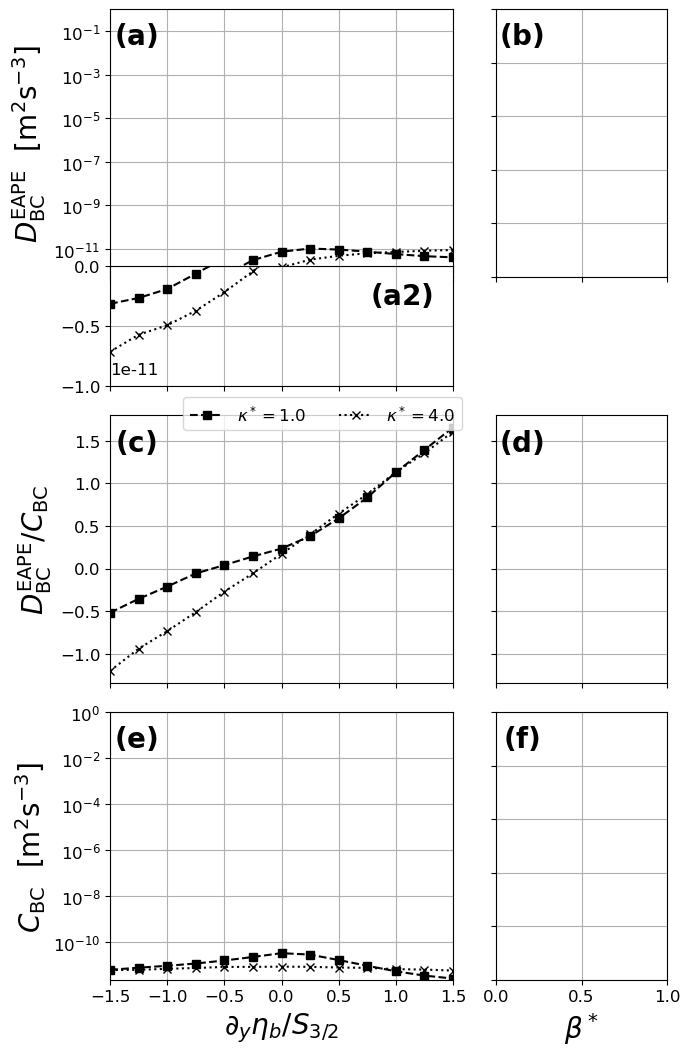

PyObject Text(47.66562499999999, 0.5, '$C_\\mathrm{BC} \\ \\ [ \\mathrm{m}^2 \\mathrm{s}^{-3} ]$')

In [16]:
using FileIO, JLD2

# fn = data_dir*"modal_nrg_budget_xspace_nu0_kap1_betas.jld"

# a = load(fn);

# for (k,v) in a["jld_data"]
#     @eval $(Symbol(k)) = $(v)
# end

########################################################################3
# BETAS
########################################################################3
##########################################################################
fig, ax = plt.subplots(4,2, figsize=(6,10), width_ratios=[2.,1.], height_ratios=[1.,0.3,1.,1.])
fig.tight_layout(pad=0.0)

ax1=ax[5]; ax2=ax[7]; ax3=ax[8]

ax[6].axis("off")

lsize = 20
tsize = 12

# x = betas ./ ((U[1]/2) * Ld^-2)



# ############################################################################
# ax1.plot(x[1:end-1], 2 * DS_nu0_kap0p125[1:end-1, 2] , color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x, 2 * DS_nu0_kap0p25[:, 2] , color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x, 2 * DS_nu0_kap0p5[:, 2], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax1.plot(x, 2 * DS_nu0_kap1[:, 2], color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")


# ax1.set_yscale("log")


# ############################################################################
# ax2.plot(x[1:end-1], 2 * DS_nu0_kap0p125[1:end-1, 2] ./ BC_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x, 2 * DS_nu0_kap0p25[:, 2] ./ BC_nu0_kap0p25, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, 2 * DS_nu0_kap0p5[:, 2] ./ BC_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax2.plot(x, 2 * DS_nu0_kap1[:, 2] ./ BC_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")


# ############################################################################
# ax3.plot(x[1:end-1], BC_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax3.plot(x, BC_nu0_kap0p25, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax3.plot(x, BC_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax3.plot(x, BC_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")



# ax3.set_yscale("log")


# ############################################################################

ax1.set_xticklabels([])
ax2.set_xticklabels([])

ax1.set_yticklabels([])
ax2.set_yticklabels([])
ax3.set_yticklabels([])


# ax1.set_xlim(x[1], x[end])
# ax2.set_xlim(x[1], x[end])
# ax3.set_xlim(x[1], x[end])


ax1.tick_params(labelsize=tsize)
ax2.tick_params(labelsize=tsize)
ax3.tick_params(labelsize=tsize)

# ax3.set_yscale("log")

ax1.yaxis.offsetText.set(size=tsize)
ax2.yaxis.offsetText.set(size=tsize)
ax3.yaxis.offsetText.set(size=tsize)

ax1.grid()
ax2.grid()
ax3.grid()

ax3.set_xlabel(L"\beta^*", fontsize=lsize)

ax1.text(0.15, 0.9, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.15, 0.9, L"\mathbf{(d)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.15, 0.9, L"\mathbf{(f)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);


############################################################################

############################################################################

############################################################################

############################################################################

####################################################################

####################################################################

############################################################################

############################################################################

############################################################################

# BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

function define_xspace_modal_nrg_terms(mu_loc)

    CBC = zeros(length(h0s)) .* NaN
    DBC_over_CBC = zeros(length(h0s)) .* NaN
    DBC = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)
    
        CBC[h_ind] = xmn[6]
        DBC_over_CBC[h_ind] = 2 * xmn[9] / xmn[6]
        DBC[h_ind] = 2 * xmn[9]

    end
        
    return CBC, DBC_over_CBC, DBC
end

CBC_mu3, DBC_over_CBC_mu3, DBC_mu3 = define_xspace_modal_nrg_terms(mus[3])

CBC_mu5, DBC_over_CBC_mu5, DBC_mu5 = define_xspace_modal_nrg_terms(mus[5])


############################################################################

############################################################################


ax1=ax[1]; ax1b=ax[2]; ax2=ax[3]; ax3=ax[4];

x= h0s ./ S32
x2 = x[7:end]

ax1b.axis("off")

############################################################################

# ax1.plot(x2[1:end-1], 2 * DS_nu0_kap0p125[1:end-1, 2] , color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x[4:end], 2 * DS_nu0_kap0p25[4:end, 2] , color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x[4:end], 2 * DS_nu0_kap0p5[4:end, 2], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x[5:end], DBC_mu3[5:end], color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax1.plot(x[6:end], 2 * DS_nu0_kap2[6:end, 2], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x[7:end], DBC_mu5[7:end], color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


# ax2.plot(x, TT_nu0_kap2 ./ BC_nu0_kap2, color="k", marker="o", linestyle="--", label=L"\kappa^* = 2.0")
# ax2.plot(x, TT_nu0_kap1 ./ BC_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, TT_nu0_kap0p5 ./ BC_nu0_kap0p5, color="k", marker="d", linestyle="--", label=L"\kappa^* = 0.5")


# ax1.set_ylabel(L"D_\mathrm{BC, \, EAPE} \ \ [ \mathrm{m}^2 \mathrm{s}^{-3} ]", fontsize=lsize)
# ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
# ax1.legend(fontsize=tsize)

ax1.set_yscale("log")

############################################################################


pos = ax1b.get_position().get_points()  # [[xmin, ymin], [xmax, ymax]]

left = pos[1,1]
bottom = pos[1,2]

width = pos[2,1] - left
height = pos[2,2] - bottom

ax1b = fig.add_axes([left, bottom, width, height*1.5])


# ax1b.plot(x2[1:end-3], 2 * DS_nu0_kap0p125[1:end-3, 2] , color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1b.plot(x[4:end], 2 * DS_nu0_kap0p25[4:end, 2] , color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1b.plot(x[1:end-3], 2 * DS_nu0_kap0p5[1:end-3, 2], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1b.plot(x[1:end-3], DBC_mu3[1:end-3], color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax1b.plot(x[1:end-3], 2 * DS_nu0_kap2[1:end-3, 2], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1b.plot(x[1:end-3], DBC_mu5[1:end-3], color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax1b.set_ylim(-1.e-11, 0.)

# ax1b.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

# ax1b.get_yaxis().set_major_formatter(plt.LogFormatter(10,  labelOnlyBase=false))

# ax1b.yaxis.get_offset_text().set_position((0.,-1000))
ax1b.yaxis.get_offset_text().set_visible(false)
ax1b.text(0.0,0.1, "1e-11", fontsize=tsize, transform = ax1b.transAxes)


############################################################################
# ax2.plot(x2[1:end-1], 2 * DS_nu0_kap0p125[1:end-1, 2] ./ BC_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], 2 * DS_nu0_kap0p25[4:end, 2] ./ BC_nu0_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, 2 * DS_nu0_kap0p5[:, 2] ./ BC_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, DBC_over_CBC_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, 2 * DS_nu0_kap2[:, 2] ./ BC_nu0_kap2, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x, DBC_over_CBC_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")



# ax2.plot(x, TT_nu0_kap2 ./ BC_nu0_kap2, color="k", marker="o", linestyle="--", label=L"\kappa^* = 2.0")
# ax2.plot(x, TT_nu0_kap1 ./ BC_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, TT_nu0_kap0p5 ./ BC_nu0_kap0p5, color="k", marker="d", linestyle="--", label=L"\kappa^* = 0.5")


# ax2.set_ylabel(L"D_\mathrm{BC, \, EAPE} / C_\mathrm{BC}", fontsize=lsize)
# ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)



############################################################################
# ax3.plot(x2[1:end-1], BC_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax3.plot(x[4:end], BC_nu0_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax3.plot(x, BC_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax3.plot(x, CBC_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax3.plot(x, BC_nu0_kap2, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax3.plot(x, CBC_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


ax3.set_yscale("log")

# ax3.set_ylabel(L"C_\mathrm{BC} \ \ [ \mathrm{m}^2 \mathrm{s}^{-3} ]", fontsize=lsize)



############################################################################
ax2.legend(loc="upper right", fontsize=tsize, ncol=2,bbox_to_anchor=(1.05,1.1))

ax1.set_xticklabels([])
ax1b.set_xticklabels([])
ax2.set_xticklabels([])


ax1.set_xlim(x[1], x[end])
ax1b.set_xlim(x[1], x[end])
ax2.set_xlim(x[1], x[end])
ax3.set_xlim(x[1], x[end])


ax1.tick_params(labelsize=tsize)
ax1b.tick_params(labelsize=tsize)
ax2.tick_params(labelsize=tsize)
ax3.tick_params(labelsize=tsize)

ax1.yaxis.offsetText.set(size=tsize)
ax1b.yaxis.offsetText.set(size=tsize)
ax2.yaxis.offsetText.set(size=tsize)
ax3.yaxis.offsetText.set(size=tsize)

ax1.grid()
ax1b.grid()
ax2.grid()
ax3.grid()

ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

ax1.text(0.075, 0.9, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax1b.text(0.85, 0.75, L"\mathbf{(a2)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax1b.transAxes);
ax2.text(0.075, 0.9, L"\mathbf{(c)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.075, 0.9, L"\mathbf{(e)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);


r1_ymin = minimum([ax[1].get_ylim()[1], ax[5].get_ylim()[1]])
r1_ymax = maximum([ax[1].get_ylim()[2], ax[5].get_ylim()[2]]); # r1_ymax = 3e-11
r2_ymin = minimum([ax[3].get_ylim()[1], ax[7].get_ylim()[1]])
r2_ymax = maximum([ax[3].get_ylim()[2], ax[7].get_ylim()[2]])
r3_ymin = minimum([ax[4].get_ylim()[1], ax[8].get_ylim()[1]])
r3_ymax = maximum([ax[4].get_ylim()[2], ax[8].get_ylim()[2]])



ax[1].set_ylim(r1_ymin, r1_ymax)
ax[3].set_ylim(r2_ymin, r2_ymax)
ax[4].set_ylim(r3_ymin, r3_ymax)
ax[5].set_ylim(r1_ymin, r1_ymax)
ax[7].set_ylim(r2_ymin, r2_ymax)
ax[8].set_ylim(r3_ymin, r3_ymax)


ax1.set_ylabel(L"D_\mathrm{BC}^\mathrm{EAPE} \ \ [ \mathrm{m}^2 \mathrm{s}^{-3} ]", fontsize=lsize)

ax2.set_ylabel(L"D_\mathrm{BC}^\mathrm{EAPE} / C_\mathrm{BC}", fontsize=lsize)
ax3.set_ylabel(L"C_\mathrm{BC} \ \ [ \mathrm{m}^2 \mathrm{s}^{-3} ]", fontsize=lsize)



# savefig("./drag_figs/modal_xspace_budget_terms_beta_merged.pdf",bbox_inches="tight")




sys:1: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.


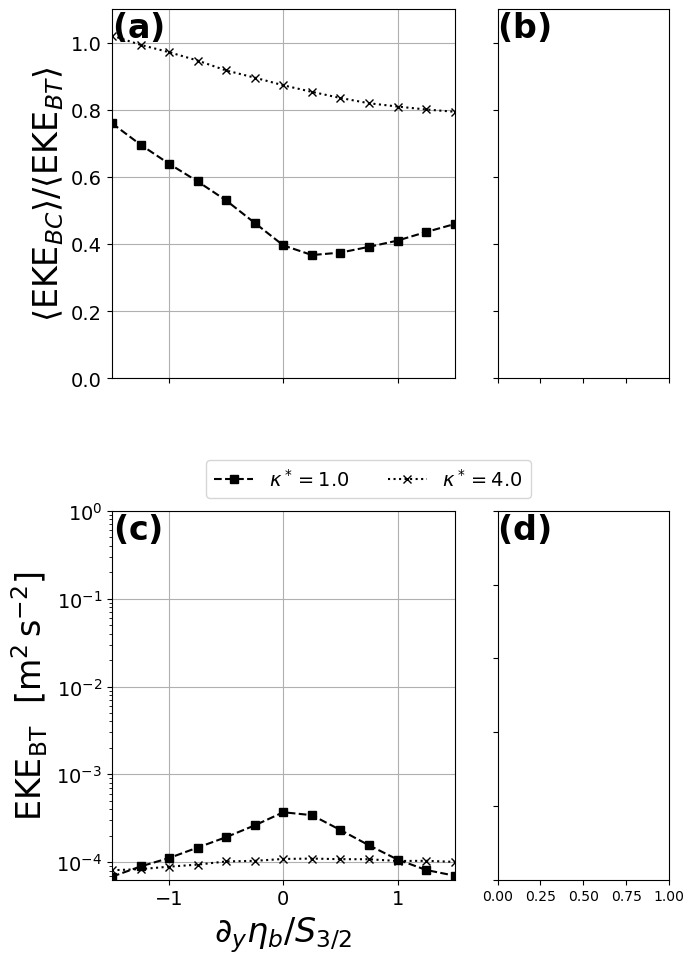

In [17]:
# LOAD BETAS


########################################################################3
##########################################################################

fig, ax = plt.subplots(3,2, figsize=(6,9), height_ratios=[1.,0.2,1.], width_ratios=[1.0,0.5])
fig.tight_layout(pad=0.0)

ax[2].axis("off")
ax[5].axis("off")

ax1=ax[4]; ax2=ax[6]; 

lsize = 24
tsize = 14

# x = betas / (U[1] * Ld^-2 / 2 ) 

# ############################################################################
# ax1.plot(x[1:end-1], BCEKE_nu0_kap0p125[1:end-1] ./ BTEKE_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x, BCEKE_nu0_kap0p25 ./ BTEKE_nu0_kap0p25, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x, BCEKE_nu0_kap0p5 ./ BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax1.plot(x, BCEKE_nu0_kap1 ./ BTEKE_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")


# ax1.set_xlim(x[1], x[end])
# ax1.set_ylim(0.0, 1.1)

# ax1.set_xticklabels([])

# ax1.tick_params(labelsize=tsize, which="both")

# ax1.grid()



# ##############################################################################

# ax2.plot(x[1:end-1], BTEKE_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x, BTEKE_nu0_kap0p25, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
# ax2.plot(x, BTEKE_nu0_kap1, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")

# ax2.set_yscale("log")

# ax2.set_xlim(x[1], x[end])
# ax2.grid()

# ax2.set_xlabel(L"\beta^* ",fontsize=lsize)

# ax2.tick_params(labelsize=tsize, which="both")


# ############################################################################

############################################################################

############################################################################

############################################################################

############################################################################

############################################################################

####################################################################

############################################################################

############################################################################

############################################################################

# BTKE_x, BCKE_x, BCEAPE_x, LT_x, TT_x, BC_x, NL_x, DBT_x, DBC_x, resid_x)

function define_modal_nrg_ratios(mu_loc)

    EKEBC_over_EKEBT = zeros(length(h0s)) .* NaN
    EKE_BT = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
            
        a = load(data_dir*jld_name(model_params,62.95))

        xmn = a["jld_data"]["two_layer_xspace_modal_nrg_budget"]  # xspace modal nrgs (xmn)
    
        EKEBC_over_EKEBT[h_ind] = xmn[2] / xmn[1]          # 
        EKE_BT[h_ind] = xmn[1]
    
    end
        
    return EKEBC_over_EKEBT, EKE_BT
end

EKEBC_over_EKEBT_mu3, EKE_BT_mu3 = define_modal_nrg_ratios(mus[3])

EKEBC_over_EKEBT_mu5, EKE_BT_mu5 = define_modal_nrg_ratios(mus[5])



############################################################################

############################################################################


ax1=ax[1]; ax2=ax[3];

x= h0s ./ S32
x2 = x[7:end]


############################################################################
# ax1.plot(x2[1:end-1], BCEKE_nu0_kap0p125[1:end-1] ./ BTEKE_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax1.plot(x[4:end], BCEKE_nu0_kap0p25[4:end] ./ BTEKE_nu0_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax1.plot(x, BCEKE_nu0_kap0p5 ./ BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, EKEBC_over_EKEBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax1.plot(x, BCEKE_nu0_kap2 ./ BTEKE_nu0_kap2, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, EKEBC_over_EKEBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")


# ax1.plot(x, BCEKE_nu0_mu1 ./ BTEKE_nu0_mu1, color="r", marker="x", linestyle="--", label=L"\mu^* = 1.0")

ax1.set_ylabel(L" \langle \mathrm{EKE}_{BC} \rangle / \langle \mathrm{EKE}_{BT} \rangle ", fontsize=lsize)

ax1.set_xlim(x[1], x[end])
# ax1.set_ylim(ax1.get_ylim()[1], 1.3)  # minimum(BCEKE_nu0_kap0p25 ./ BTEKE_nu0_kap0p25), 1.3) # 
ax1.set_ylim(0.0, 1.1)

ax1.set_xticklabels([])
# ax1.set_yscale("log")

ax1.tick_params(labelsize=tsize, which="both")


ax1.grid()



##############################################################################

# ax2.plot(x2[1:end-1], BTEKE_nu0_kap0p125[1:end-1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
# ax2.plot(x[4:end], BTEKE_nu0_kap0p25[4:end], color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, BTEKE_nu0_kap0p5, color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, EKE_BT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, BTEKE_nu0_kap1, color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x, EKE_BT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax2.set_yscale("log")

ax2.set_xlim(x[1], x[end])
ax2.grid()

# # ax2.legend(fontsize=tsize)

# ax2.set_ylabel(L"\int \mathrm{NL}_\mathrm{BC} 2 \ \mathrm{d} k \, / \, \int  \mathrm{NL}_\mathrm{BT} \ \mathrm{d} k",fontsize=lsize)
ax2.set_ylabel(L"\mathrm{EKE}_\mathrm{BT} \ \ [ \mathrm{m}^2 \, \mathrm{s}^{-2} ]",fontsize=lsize)
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2} ",fontsize=lsize)

ax2.tick_params(labelsize=tsize, which="both")


#######################
ax1.legend(fontsize=tsize, loc="lower right", bbox_to_anchor=(1.25,-0.35), ncol=2)


r1_ymin = minimum([ax[1].get_ylim()[1], ax[4].get_ylim()[1]])
r1_ymax = maximum([ax[1].get_ylim()[2], ax[4].get_ylim()[2]]); # r1_ymax = 3e-11
r2_ymin = minimum([ax[3].get_ylim()[1], ax[6].get_ylim()[1]])
r2_ymax = maximum([ax[3].get_ylim()[2], ax[6].get_ylim()[2]])



ax[1].set_ylim(r1_ymin, r1_ymax)
ax[3].set_ylim(r2_ymin, r2_ymax)
ax[4].set_ylim(r1_ymin, r1_ymax)
ax[6].set_ylim(r2_ymin, r2_ymax)

ax[4].set_yticklabels([])
ax[6].set_yticklabels([])

ax[1].set_xticklabels([])
ax[4].set_xticklabels([])


ax[1].text(0.075, 0.95, L"\mathbf{(a)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[3].text(0.075, 0.95, L"\mathbf{(c)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);

ax[4].text(0.15, 0.95, L"\mathbf{(b)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[6].text(0.15, 0.95, L"\mathbf{(d)}", fontsize=lsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);

# savefig("./drag_figs/modal_nrgs_slope_n_beta.pdf",bbox_inches="tight")



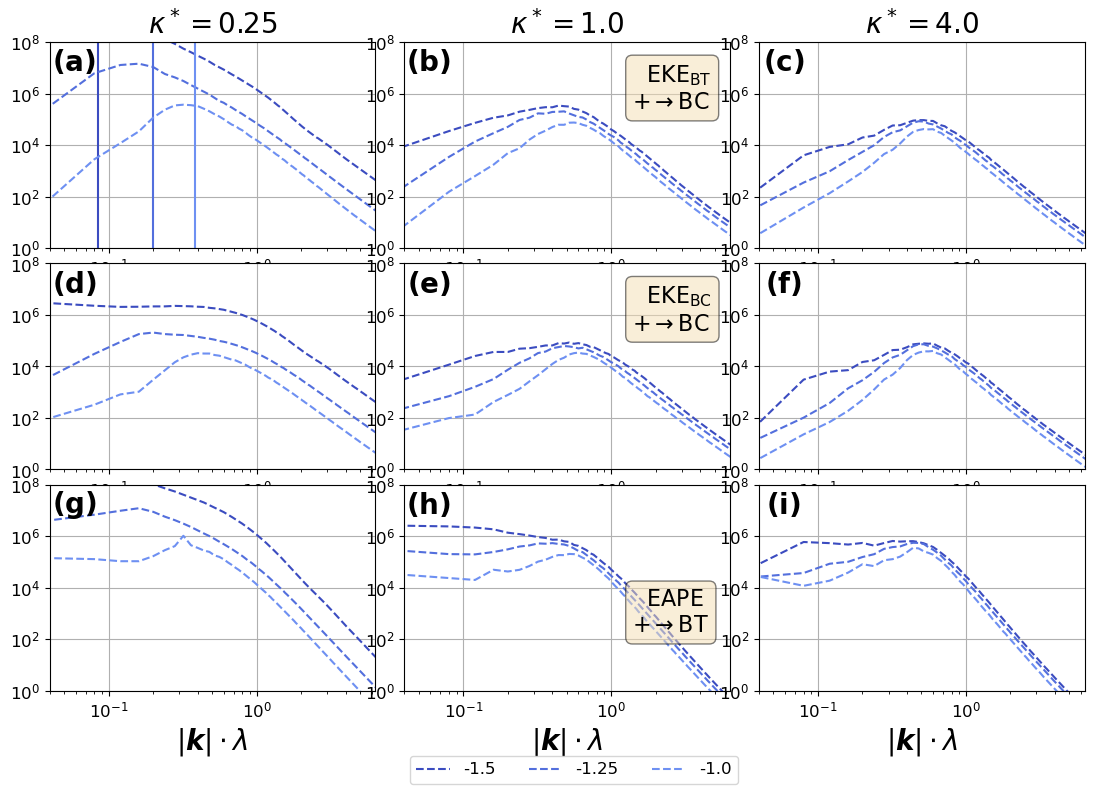

In [16]:

# a plot of KE_1 from all six combos of rho and U
fig,ax = PyPlot.subplots(3,3,figsize=(10.5, 6.5))
fig.tight_layout(pad=-1.0)

# h_ind=17
xmax_ind = 160
x = grid.kr .* Ld

fsize = 20
bsize = 16
lsize = 12

betas_zeta = [betas[7], betas[8], betas[9]]
mus_zeta = [mus[2], mus[4], mus[6]]


####################################################################

####################################################################

for i in range(1,3) # length(h0s))

    h_ind = i
    lt = "dashed"

    h0 = (0., 0.0)
    kappa_loc = kappas[1]
    mu_loc = mus[2]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas_zeta[i]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
  
    a = load(data_dir*jld_name(model_params,62.95))

    norm = 1 # (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld)

    ax[1].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,1] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    ax[1].axvline(a["jld_data"]["two_layer_modal_length_scales"][1]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    # ax[1].axvline(sqrt(abs(topo_PV[2]) / a["jld_data"]["two_layer_vBT_scale"]) * Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[2].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,2] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    # ax[2].axvline(a["jld_data"]["two_layer_modal_length_scales"][2]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[3].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,3] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)

    

    # for kappa* = 1.0
    mu_loc = mus[4]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))

    norm = 1 # (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld)

    ax[4].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,1] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    # ax[4].axvline(a["jld_data"]["two_layer_modal_length_scales"][1]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[5].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,2] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    # ax[5].axvline(a["jld_data"]["two_layer_modal_length_scales"][2]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[6].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,3] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)

    # for kappa* = 4.0
    mu_loc = mus[6]
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)
        
    a = load(data_dir*jld_name(model_params,62.95))

    norm = 1 # (a["jld_data"]["two_layer_vBT_scale"]^-3 / Ld)

    ax[7].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,1] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    # ax[7].axvline(a["jld_data"]["two_layer_modal_length_scales"][1]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[8].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,2] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)
    # ax[8].axvline(a["jld_data"]["two_layer_modal_length_scales"][2]*Ld, color=h_color(h0s[h_ind],hc_range,colors))
    
    ax[9].plot(x, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,3] .* norm, label=string(round(h0s[h_ind] / S32, sigdigits=3)), color=h_color(h0s[h_ind],hc_range,colors),linestyle=lt)


    GC.gc()
end


####################################################################################
ax[1].set_xticklabels([])
ax[2].set_xticklabels([])
ax[4].set_xticklabels([])
ax[5].set_xticklabels([])
ax[7].set_xticklabels([])
ax[8].set_xticklabels([])

ax[4].set_yticklabels([])
ax[5].set_yticklabels([])
ax[6].set_yticklabels([])
ax[7].set_yticklabels([])
ax[8].set_yticklabels([])
ax[9].set_yticklabels([])

ax[6].legend(fontsize=lsize, bbox_to_anchor=(1.05,-0.275), ncol=3)


ax[1].set_title(L"\kappa^* = 0.25", fontsize=fsize)
ax[4].set_title(L"\kappa^* = 1.0", fontsize=fsize)
ax[7].set_title(L"\kappa^* = 4.0", fontsize=fsize)

ax[3].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[6].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)

ax[9].set_xlabel(L" | \boldsymbol{k} | \cdot \lambda", fontsize=fsize)


# ax3.set_ylim(ax3.get_ylim()[1],1.2)

ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);


ymins = [10^0, 10^0, 10^0]
ymaxes = ymins .* 10^8

for i in range(1,length(ax))
    
    axn = ax[i]
    axn.grid()
    axn.tick_params(labelsize=lsize)
    axn.set_xlim(x[2], x[xmax_ind])
    
end


for i in range(1,size(ax)[1])

    ax[i].set_ylim(ymins[i], ymaxes[i])
    ax[i+size(ax)[1]].set_ylim(ymins[i], ymaxes[i])
    ax[i+2*size(ax)[1]].set_ylim(ymins[i], ymaxes[i])

    ax[i].set_yscale("log")
    ax[i+size(ax)[1]].set_yscale("log")
    ax[i+2*size(ax)[1]].set_yscale("log")

    ax[i].set_xscale("log")
    ax[i+size(ax)[1]].set_xscale("log")
    ax[i+2*size(ax)[1]].set_xscale("log")
end

# ax[3].set_ylim(ax[3].get_ylim()[1], ax[3].get_ylim()[2]+0.2)
# ax[6].set_ylim(ax[6].get_ylim()[1], ax[6].get_ylim()[2]+0.2)



###################################################################
###################################################################

plot_info_box(ax[4], L"\ \ \mathrm{EKE}_\mathrm{BT}", 0.7, 0.9, "BC", bsize)
plot_info_box(ax[5], L"\ \ \mathrm{EKE}_\mathrm{BC}", 0.7, 0.9, "BC", bsize)
plot_info_box(ax[6], L"\ \ \mathrm{EAPE}", 0.7, 0.5, "BT", bsize)


# savefig("./drag_figs/nrgs_kspace.pdf",bbox_inches="tight", transparent=true)



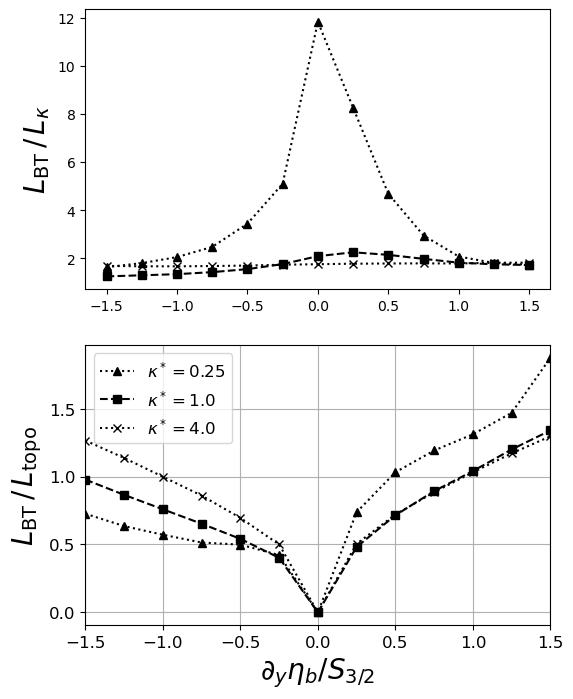

(-1.5, 1.5)

In [46]:
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax1=ax[1]; ax2=ax[2];

lsize = 20
tsize = 12

x = h0s ./ S32
x2 = x[7:end-1]

############################################################################

############################################################################
vs_ind = 1

# vel scales are twelve
# total BT, U BT, V BT, total BC, U BC, V BC, (7) total L1, U L1, V L1, total L2, U L2, V L2

############################################################################

############################################################################

function define_modal_scale_ratios(mu_loc, vel_scale)

    LBC_over_LBT = zeros(length(h0s)) .* NaN
    LBT = zeros(length(h0s)) .* NaN
        
    for h_ind in range(1, length(h0s))
    
        h0 = (h0s[h_ind], 0.0)
        kappa_loc = kappas[1]
        
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
        global topo_PV, eta = define_topo(model_params)
        global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

        if h_ind != 14
            a = load(data_dir*jld_name(model_params,62.95))

            c1 = 5
            c2 = 0.36
            
            v_scale = a["jld_data"]["two_layer_vBT_scale"]  # vel_scale[h_ind, vs_ind] #  U[1]/2 #  
            # LBC_over_LBT[h_ind] = a["jld_data"]["two_layer_modal_length_scales"][1] / (mu_loc /  (v_scale) ) * 2 * pi

            # L_VG = (Ld * c1 *exp(c2 / (mu_loc * Ld / (U[1]/2))))  / 2 / pi
            # L_VG = (Ld * c1 *exp(c2 / (mu_loc * Ld / (v_scale))))  / 2 / pi
            
            # LBC_over_LBT[h_ind] = a["jld_data"]["two_layer_modal_length_scales"][1] * (L_VG)

            L_R = sqrt(abs(v_scale / topo_PV[2])) 
            

            LBT[h_ind] = a["jld_data"]["two_layer_modal_length_scales"][1] * Ld # / (mu_loc /  (v_scale) ) # a["jld_data"]["two_layer_modal_length_scales"][1]^-1 / Ld  # L_VG  # 
            LBC_over_LBT[h_ind] = a["jld_data"]["two_layer_modal_length_scales"][1] * L_R
        end
        
    end
        
    return LBT.^-1, LBC_over_LBT.^-1
end

LBT_mu1, LBC_over_LBT_mu1 = define_modal_scale_ratios(mus[2], vel_scales_kap0p25)

LBT_mu3, LBC_over_LBT_mu3 = define_modal_scale_ratios(mus[4], vel_scales_kap1)

LBT_mu5, LBC_over_LBT_mu5 = define_modal_scale_ratios(mus[6], vel_scales_kap4)



############################################################################

############################################################################

ax1.plot(x, LBT_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, LS_nu0_kap0p5[:,2] ./ LS_nu0_kap0p5[:,1], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax1.plot(x, LBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, LS_nu0_kap2[:,2] ./ LS_nu0_kap2[:,1], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax1.plot(x, LBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax1.set_ylabel(L"L_\mathrm{BT} \, / \, L_{\kappa}  ", fontsize=lsize)


# ax2.plot(x2, LS_nu0_kap0p125[1:end-1,2] ./ LS_nu0_kap0p125[1:end-1,1], color="k", marker=".", linestyle="-.", label=L"\kappa^* = 0.125")
ax2.plot(x, LBC_over_LBT_mu1, color="k", marker="^", linestyle="dotted", label=L"\kappa^* = 0.25")
# ax2.plot(x, LS_nu0_kap0p5[:,2] ./ LS_nu0_kap0p5[:,1], color="k", marker="d", linestyle="-", label=L"\kappa^* = 0.5")
ax2.plot(x, LBC_over_LBT_mu3, color="k", marker="s", linestyle="--", label=L"\kappa^* = 1.0")
# ax2.plot(x, LS_nu0_kap2[:,2] ./ LS_nu0_kap2[:,1], color="k", marker="o", linestyle="-.", label=L"\kappa^* = 2.0")
ax2.plot(x,LBC_over_LBT_mu5, color="k", marker="x", linestyle="dotted", label=L"\kappa^* = 4.0")

ax2.set_ylabel(L"L_\mathrm{BT}  \, / \, L_\mathrm{topo} ", fontsize=lsize)
# ax3.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)
ax2.legend(fontsize=tsize)
ax2.set_xlabel(L"\partial_y \eta_b / S_{3/2}", fontsize=lsize)

ax2.grid()

ax2.tick_params(labelsize=tsize, which="both")

# ax1.set_yscale("log")

ax2.set_xlim(x[1], x[end])


# ax2.set_ylim(0., 4)



############################################################################

############################################################################

# savefig("./drag_figs/BC_BT_scale_ratio.pdf",bbox_inches="tight")


In [24]:
betas[6]

-1.5580057896568962e-12

In [27]:

i=7
j=1
k=2


h0 = (0.0, 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]
beta = betas[7]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)


global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name(model_params,62.95))

    

# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_0.000E+00_beta3.116E-12_uni_shear_uni_strat_mu8.826E-08_kappa0.000E+00_nu0.000E+00_res1024_yr57.7.jld


# betas that don't equilibrate:
# kappa*=4.0 : beta10+; beta11+ are decreasing, i.e., there is no instability???
# kappa*=2.0 : beta12+ (11 has growth, but averaged energy budget still closes)
# kappa*=1.0 : beta13
# kappa*=0.5 : okay
# kappa*=0.25 : definitely 10 good; maybe 11? secular growth but low residuals
# kappa*=0.125 : beta11+


Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.0338179, "t"=>[1.70411e9, 1.70…

In [28]:
    ψ = a["jld_data"]["psi_yrs_end"]

    @unpack_mod_params model_params

    dev = grid.device
    T = eltype(grid)
    A = device_array(dev)

    rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE)

    # parameters
    nlayers = 2
    δ = [params.H[1]/sum(params.H), params.H[2]/sum(params.H)]
    g′ = g * (rho[2] -   rho[1]) / rho0 # reduced gravity at each interface
    Ld1 = (f0^2 / (g′ * params.H[1]))^-0.5
    ∂yηb = params.topographic_pv_gradient[2] / (f0 / params.H[end])
    
    # assigning basic variables
    ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
    ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])

    ψBCh = deepcopy(vars.uh[:,:,1])
    ψBTh = deepcopy(vars.uh[:,:,1])

    mul2D!(ψBCh, rfftplan, ψBC)
    mul2D!(ψBTh, rfftplan, ψBT)
    
    U₁, U₂, = view(params.U, :, :, 1), view(params.U, :, :, 2)
    
    S32 = CUDA.@allowscalar f0 * U₁[1,1] / g′

    # streamfunction stuff
    ∂xψBTh = im * grid.kr .* ψBTh
    ∂yψBTh = im * grid.l .* ψBTh
    
    ∂xψBT = deepcopy(vars.u[:,:,1])
    ∂yψBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBT, rfftplan, im * grid.kr .* ψBTh)
    ldiv2D!(∂yψBT, rfftplan, im * grid.l .* ψBTh)

    ∂xψBCh = im * grid.kr .* ψBCh
    ∂yψBCh = im * grid.l .* ψBCh

    ∂xψBC = deepcopy(vars.u[:,:,1])
    ∂yψBC = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBC, rfftplan, im * grid.kr .* ψBCh)
    ldiv2D!(∂yψBC, rfftplan, im * grid.l .* ψBCh)

    # ∂xψBT_∂yψBCh = deepcopy(vars.uh[:,:,1])

    # mul2D!(∂xψBT_∂yψBCh, rfftplan, ∂xψBT * ∂yψBC)

    # ∂yψBT_∂xψBCh = deepcopy(vars.uh[:,:,1])

    # mul2D!(∂yψBT_∂xψBCh, rfftplan, ∂yψBT * ∂xψBC)

    J_ψBT_ψBCh = deepcopy(vars.uh[:,:,1])

    mul2D!(J_ψBT_ψBCh, rfftplan, ∂xψBT * ∂yψBC - ∂yψBT * ∂xψBC)  #  (uBT .* vBC .- uBC .* vBT))
    
    # nonlinear terms
    ζ = deepcopy(vars.v)
    ζ[:,:,1] .= irfft(-grid.Krsq .* vars.ψh[:,:,1], grid.ny)
    ζ[:,:,2] .= irfft(-grid.Krsq .* vars.ψh[:,:,2], grid.ny)
    ζ₁, ζ₂ = view(ζ, :, :, 1), view(ζ, :, :, 2)

    ζBCh = - grid.Krsq .* ψBCh
    ζBTh = - grid.Krsq .* ψBTh

    ζBC = deepcopy(vars.u[:,:,1])
    ζBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(ζBC, rfftplan, - grid.Krsq .* ψBCh)
    ldiv2D!(ζBT, rfftplan, - grid.Krsq .* ψBTh)

    ∂xζBCh = im * grid.kr .* ζBCh
    ∂xζBTh = im * grid.kr .* ζBTh

    ∂yζBCh = im * grid.l .* ζBCh
    ∂yζBTh = im * grid.l .* ζBTh

    ∂xζBC = deepcopy(vars.u[:,:,1])
    ∂xζBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xζBC, rfftplan, im * grid.kr .* ζBCh)
    ldiv2D!(∂xζBT, rfftplan, im * grid.kr .* ζBTh)

    ∂yζBC = deepcopy(vars.u[:,:,1])
    ∂yζBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂yζBC, rfftplan, im * grid.l .* ζBCh)
    ldiv2D!(∂yζBT, rfftplan, im * grid.l .* ζBTh)

    ##
    ζBT∂xψBTh = deepcopy(vars.uh[:,:,1])
    ζBT∂yψBTh = deepcopy(vars.uh[:,:,1])

    ζBC∂xψBCh = deepcopy(vars.uh[:,:,1])
    ζBC∂yψBCh = deepcopy(vars.uh[:,:,1])

    ζBC∂xψBTh = deepcopy(vars.uh[:,:,1])
    ζBC∂yψBTh = deepcopy(vars.uh[:,:,1])

    ζBT∂xψBCh = deepcopy(vars.uh[:,:,1])
    ζBT∂yψBCh = deepcopy(vars.uh[:,:,1])

    ψBC∂xψBTh = deepcopy(vars.uh[:,:,1])
    ψBC∂yψBTh = deepcopy(vars.uh[:,:,1])

    
    mul2D!(ζBT∂xψBTh, rfftplan, ζBT .* ∂xψBT)
    mul2D!(ζBT∂yψBTh, rfftplan, ζBT .* ∂yψBT)

    mul2D!(ζBC∂xψBCh, rfftplan, ζBC .* ∂xψBC)
    mul2D!(ζBC∂yψBCh, rfftplan, ζBC .* ∂yψBC)

    mul2D!(ζBC∂xψBTh, rfftplan, ζBC .* ∂xψBT)
    mul2D!(ζBC∂yψBTh, rfftplan, ζBC .* ∂yψBT)

    mul2D!(ζBT∂xψBCh, rfftplan, ζBT .* ∂xψBC)
    mul2D!(ζBT∂yψBCh, rfftplan, ζBT .* ∂yψBC)

    mul2D!(ψBC∂xψBTh, rfftplan, ψBC .* ∂xψBT)
    mul2D!(ψBC∂yψBTh, rfftplan, ψBC .* ∂yψBT)

    J_ψBT_ζBT = ∂xψBT .* ∂yζBT .- ∂yψBT .* ∂xζBT

    J_ψBT_ζBTh = deepcopy(vars.uh[:,:,1])
    
    mul2D!(J_ψBT_ζBTh, rfftplan, ∂xψBT .* ∂yζBT .- ∂yψBT .* ∂xζBT)

    ζ₁h = deepcopy(vars.uh[:,:,1])
    
    mul2D!(ζ₁h, rfftplan, ζ₁)
    
    # ζ₂h = rfft(ζ₂)

    ∂xζ1 = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xζ1, rfftplan, im * grid.kr .* ζ₁h)

    ############################################################################################
    w_32h = calc_w_int(vars, grid, ψ, params, model_params)
    T_Dh = @. - (f0 / H[2]) * w_32h * conj(ψBCh)
    T_Dh .+= conj.(T_Dh)

    # w_32 = deepcopy(vars.u[:,:,1])
    # ldiv2D!(w_32, rfftplan, w_32h)

    ############################################################################################
    BTEKE = @. 0.5 * (conj(ψBTh) * (grid.kr^2 * ψBTh) + ψBTh * conj(grid.kr^2 * ψBTh))

    BCEKE = @. 0.5 * grid.kr^2 * (conj(ψBCh) * ψBCh + ψBCh * conj(ψBCh))
    BCEAPE = @. 0.5 * 2 * Ld1^-2 * (conj(ψBCh) * ψBCh + ψBCh * conj(ψBCh))

    ############################################################################################
    # Baroclinic conversion term
    CBC = @. S32 * (params.f₀ / params.H[1]) * ( conj(ψBCh) * ∂xψBTh + ψBCh * conj(∂xψBTh)) # these are equivalent!

    # CBC = @. U₁ * Ld1^-2 * (conj(ψBCh) * ∂xψBTh)
    # CBC .+= conj(CBC)
    
    ############################################################################################
    # Linear BC-BT flux (flat-bottom) term
    BC2BT = @. 0.5 * U₁ * (conj(ψBTh) * ∂xζBCh + ψBTh * conj(∂xζBCh))

    ############################################################################################
    # Nonlinear terms in BT budget
    NLBT = zeros(dev, T, (grid.nkr,grid.ny,2)) .+ 0im
    @views NLBT[:,:,1] = @. conj(ψBTh) * J_ψBT_ζBTh + ψBTh * conj(J_ψBT_ζBTh)  # im * (grid.l * ζBT∂xψBTh - grid.kr * ζBT∂yψBTh)
    # NLBT[:,:,1] .+= conj.(NLBT[:,:,1])

    @views NLBT[:,:,2] = @. conj(ψBTh) * im * (grid.l * ζBC∂xψBCh - grid.kr * ζBC∂yψBCh)
    @views NLBT[:,:,2] .+= conj.(NLBT[:,:,2])

    ############################################################################################
    # Nonlinear terms in BC budget
    NLBC = zeros(dev, T, (grid.nkr,grid.ny,3)) .+ 0im

    #NLBC2BT
    @views NLBC[:,:,1] = @. conj(ψBCh) * im * (grid.l * ζBC∂xψBTh - grid.kr * ζBC∂yψBTh)
    @views NLBC[:,:,1] .+= conj.(NLBC[:,:,1])

    #NLBCEKE
    @views NLBC[:,:,2] = @. conj(ψBCh) * im * (grid.l * ζBT∂xψBCh - grid.kr * ζBT∂yψBCh)
    @views NLBC[:,:,2] .+= conj.(NLBC[:,:,2])

    #NLBCEAPE
    @views NLBC[:,:,3] = @. - 2 * Ld1^-2 * conj(ψBCh) * im * (grid.l * ψBC∂xψBTh - grid.kr * ψBC∂yψBTh)
    @views NLBC[:,:,3] .+= conj.(NLBC[:,:,3])

    NL_EAPE = @. - Ld^-2 * conj(ψBCh) * J_ψBT_ψBCh  # wrong .. product of FT is not FT of products (∂xψBTh * ∂yψBCh - ∂yψBTh * ∂xψBCh) # 
    NL_EAPE .+= conj.(NL_EAPE)

#- Ld^-2 .* psi_BC_hpf .* (uBT .* vBC .- uBC .* vBT))


513×1024 Matrix{ComplexF64}:
 -6.17523e-11+0.0im      -2122.57+0.0im  …      -2122.57+0.0im
   -1.38413e6+0.0im    -1.26072e6+0.0im        1.10289e5+0.0im
    3.57262e5+0.0im    -2.14826e5+0.0im       -1.25753e5+0.0im
      43300.5+0.0im     2.56522e5+0.0im        2.02303e5+0.0im
     -61814.0+0.0im      -23812.3+0.0im       -1.09725e5+0.0im
     -5704.83+0.0im       8992.32+0.0im  …      -6649.92+0.0im
      22445.8+0.0im      -4870.89+0.0im         -61212.6+0.0im
      13764.5+0.0im      -8947.57+0.0im          783.544+0.0im
      5583.73+0.0im      -25947.8+0.0im          7299.14+0.0im
      -392.61+0.0im      -16344.2+0.0im         -8583.55+0.0im
     -511.836+0.0im      -6534.77+0.0im  …       -6510.0+0.0im
      8232.08+0.0im      -13174.1+0.0im         -1357.08+0.0im
      -1341.6+0.0im       1047.35+0.0im          1030.48+0.0im
             ⋮                           ⋱  
 -1.76196e-28+0.0im  -5.44106e-28+0.0im       2.3493e-27+0.0im
  3.43125e-29+0.0im   5.15226e-30+0.0im     

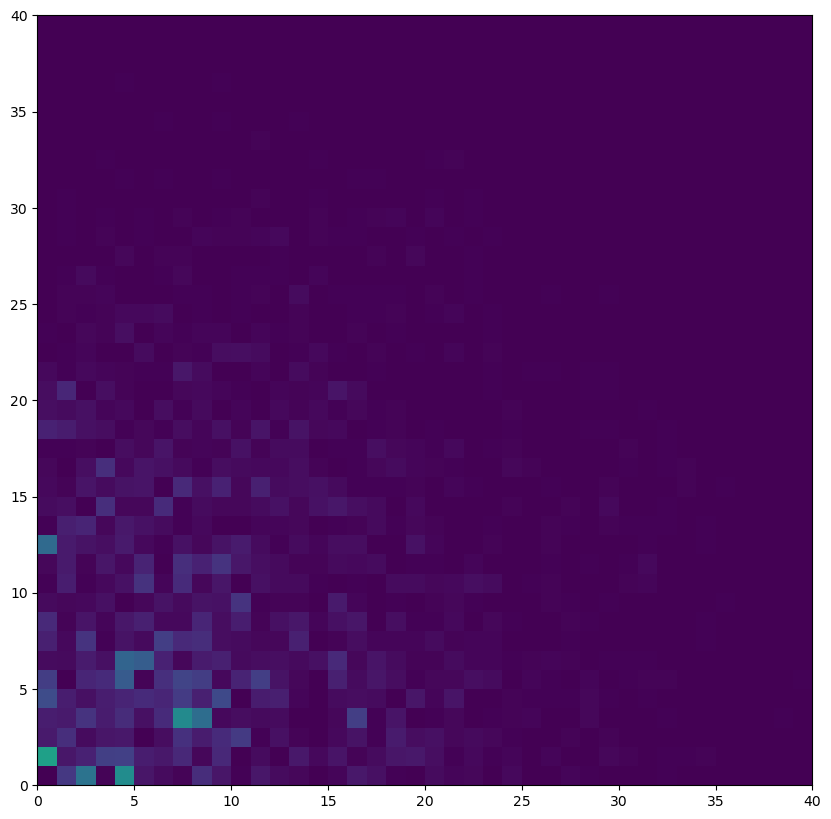

(0.0, 40.0)

In [29]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.pcolormesh(abs.(NLBC[:,:,3]))

ax.set_xlim(0,40)
ax.set_ylim(0,40)



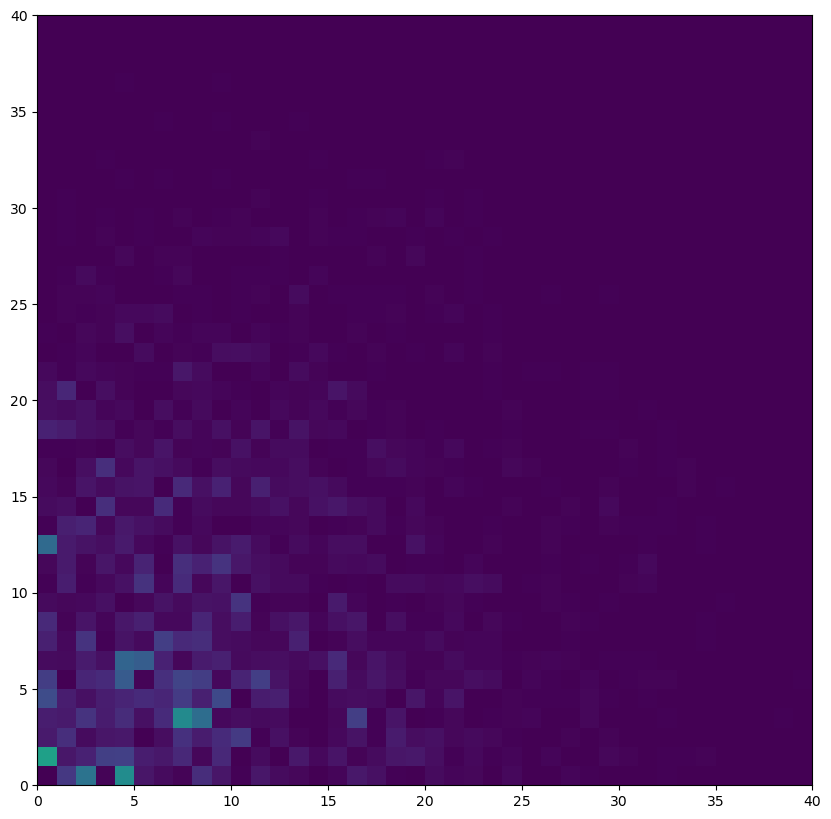

(0.0, 40.0)

In [26]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.pcolormesh(abs.(NLBC[:,:,3]))

ax.set_xlim(0,40)
ax.set_ylim(0,40)

